In [315]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle

from thesis_project.models.keyword_spotting.base_schema import KeyWordSpottingBaseConfig
from thesis_project.models.keyword_spotting.dynamic_schema import DynamicTrainingConfig

from thesis_project.training.key_word_spotting.validate_model import validate_model
from thesis_project.utils.compute_macs import compute_macs_base_model, compute_avg_rank_from_macs


#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

In [316]:
R_BREAKEVEN = 64
MAX_RANK_CAP = R_BREAKEVEN # Change to a lower value if needed
POOL_REDUCTION_FACTOR = 2

# Example usage + save figure (high DPI)
output_dir = Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz")
output_dir.mkdir(parents=True, exist_ok=True)

In [317]:
# Compute expected rank statistics from a dynamic experiment folder.
# The CSV stores ranks in a `rank` column and may contain either scalar ranks
# or per-stack ranks serialized as list-like values.


def compute_expected_rank_and_quantiles(
    per_sample_df_or_path,
    max_rank_cap: Optional[float] = None,
) -> Tuple[float, float, float, float, float]:
    if isinstance(per_sample_df_or_path, (str, Path)):
        per_sample_path = Path(per_sample_df_or_path)
        per_sample_df = pd.read_csv(per_sample_path)
    else:
        per_sample_path = None
        per_sample_df = per_sample_df_or_path

    rank_column = "rank" if "rank" in per_sample_df.columns else "rank_used"

    def _cap_rank(v: float) -> float:
        if max_rank_cap is None:
            return float(v)
        return float(min(max_rank_cap, float(v)))

    def _rank_to_scalar(value: Any) -> float:
        if pd.isna(value):
            return np.nan

        if isinstance(value, str):
            value = value.strip()
            if value.startswith("[") and value.endswith("]"):
                value = json.loads(value)

        if isinstance(value, np.ndarray):
            value = value.tolist()

        if isinstance(value, (list, tuple)):
            if len(value) == 0:
                return np.nan
            capped_values = [_cap_rank(float(v)) for v in value]
            return float(np.mean(capped_values))

        return _cap_rank(float(value))

    sample_ranks = per_sample_df[rank_column].map(_rank_to_scalar).dropna()
    if sample_ranks.empty:
        raise ValueError(f"No valid rank values found in {per_sample_path or 'per_sample_df'}")

    q25, q50, q75 = sample_ranks.quantile([0.25, 0.5, 0.75]).tolist()
    expected_rank = float(sample_ranks.mean())

    avg_acc = float("nan")
    if "correct" in per_sample_df.columns:
        avg_acc = float(per_sample_df["correct"].mean() * 100)
    elif "acc" in per_sample_df.columns:
        avg_acc = float(per_sample_df["acc"].mean())

    return expected_rank, float(q25), float(q50), float(q75), avg_acc

In [318]:
# folder with dynamic model checkpoints
parent_dir = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/"
sweep_folders = [

#'one_sided_mse_rf_2_4_6_avg',
'ce_weighted_rank_rf_2_sub',
'one_sided_mse_rf_2_4_6_sub',
'avg_rank_rf_2_sub',
'batch_mean_mse_rf_2_sub',

'avg_rank_rf_2_sub_w_0.5',
'avg_rank_rf_2_sub_w_0.75',
'ce_weighted_rank_rf_2_sub_w_0.5',
'ce_weighted_rank_rf_2_sub_w_0.75'


]
experiment_folders = []
for sweep in sweep_folders:
    sweep_dir = os.path.join(parent_dir, sweep)
    if os.path.isdir(sweep_dir):
        for exp in os.listdir(sweep_dir):
            exp_path = os.path.join(sweep_dir, exp)
            if os.path.isdir(exp_path):
                experiment_folders.append(exp_path)
experiment_folders.sort(key=lambda x: os.path.getmtime(x), reverse=False)

In [319]:
def build_all_sweep_results(
    experiment_folders: List[str],
    max_rank_cap: Optional[float] = None,
) -> List[Dict[str, Any]]:
    all_sweep_results: List[Dict[str, Any]] = []

    for exp_folder in experiment_folders:
        exp_path = Path(exp_folder)

        config_path = exp_path / "config.json"
        runtime_info_path = exp_path / "runtime_info.json"

        per_sample_df_standard_val_path = exp_path / "per_sample_df_standard_val.csv"
        per_sample_df_csv_path = exp_path / "per_sample_df.csv"
        per_sample_df_augmented_val_path = exp_path / "per_sample_df_augmented_val.csv"

        # Prefer the standard-val file when both are present.
        if per_sample_df_standard_val_path.exists():
            per_sample_df_standard_path = per_sample_df_standard_val_path
        elif per_sample_df_csv_path.exists():
            per_sample_df_standard_path = per_sample_df_csv_path
        else:
            per_sample_df_standard_path = None

        if not config_path.exists():
            print(f"Warning: Could not find config.json in {exp_folder}, skipping")
            continue
        if not runtime_info_path.exists():
            print(f"Warning: Could not find runtime_info.json in {exp_folder}, skipping")
            continue
        if per_sample_df_standard_path is None:
            print(
                f"Warning: Could not find per_sample_df_standard_val.csv or per_sample_df.csv in {exp_folder}, skipping expected rank computation"
            )
            continue

        path_to_df_augmented: Optional[str] = None
        if per_sample_df_augmented_val_path.exists():
            path_to_df_augmented = str(per_sample_df_augmented_val_path)

        with open(config_path, "r") as f:
            experiment_config = json.load(f)

        with open(runtime_info_path, "r") as f:
            runtime_info = json.load(f)

        per_sample_df = pd.read_csv(per_sample_df_standard_path)
        expected_rank, q25, q50, q75, avg_acc = compute_expected_rank_and_quantiles(
            per_sample_df,
            max_rank_cap=max_rank_cap,
        )

        router_cfg = experiment_config.get("router", {})
        loss_cfg = experiment_config.get("loss", {})

        all_sweep_results.append({
            "experiment_folder": exp_folder,
            "path_to_df_standard": str(per_sample_df_standard_path),
            "path_to_df_augmented": path_to_df_augmented,
            "expected_rank": expected_rank,
            "q25": q25,
            "q50": q50,
            "q75": q75,
            "avg_acc": avg_acc,
            "use_global_rank": router_cfg.get("use_global_rank"),
            "num_rank_outputs": router_cfg.get("num_rank_outputs"),
            "pool_mode": router_cfg.get("pool_mode"),
            "pool_reduction_factor": router_cfg.get("pool_reduction_factor"),
            "rank_loss_weight": loss_cfg.get("rank_loss_weight"),
            "rank_loss_mode": loss_cfg.get("rank_loss_mode"),
            "rank_target": (
                loss_cfg.get("base_model_rank_reference")
                if loss_cfg.get("rank_loss_mode") not in ["avg_rank", "ce_weighted_rank"]
                else None
            ),
            "router_macs": runtime_info["macs"]["router"],
            # "runtime_info": runtime_info,
        })

    return all_sweep_results


all_sweep_results = build_all_sweep_results(
    experiment_folders=experiment_folders,
    max_rank_cap=MAX_RANK_CAP,
)


In [320]:
all_sweep_results

[{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
  'path_to_df_standard': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001/per_sample_df.csv',
  'path_to_df_augmented': None,
  'expected_rank': 21.06292201137578,
  'q25': 16.660258293151855,
  'q50': 18.527493476867676,
  'q75': 21.767035484313965,
  'avg_acc': 86.83647102251754,
  'use_global_rank': True,
  'num_rank_outputs': 1,
  'pool_mode': 'subsample',
  'pool_reduction_factor': 2,
  'rank_loss_weight': 1.0,
  'rank_loss_mode': 'avg_rank',
  'rank_target': None,
  'router_macs': 785712.0},
 {'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_002',
  'path_to_df_standard': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_002/per_sample_df.csv',
  'path_to_df_augme

In [321]:
# function that filters sweep results by loss type, target rank, router outputs, pool mode, and reduction factor
def filter_sweep_results(
    sweep_results: List[Dict[str, Any]],
    loss_types=['avg_rank', 'ce_weighted_rank', 'batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs=[1, 3],
    rank_targets=[None, 10, 20, 30],
    pool_modes=['avg', 'max', 'subsample'],
    pool_reduction_factors=[2, 4, 6],
    rank_loss_weights=[1,5,10,15,20]
) -> List[Dict[str, Any]]:
    
    # check that None is in the target ranks if any of the loss types that don't use a fixed target rank are included in the filter criteria
    if any(loss in loss_types for loss in ["avg_rank", "ce_weighted_rank"]):
        assert None in rank_targets, "Filter criteria includes loss types that don't use a fixed target rank (avg_rank, ce_weighted_rank) but None is not included in the target ranks filter criteria. Please include None in target_ranks to allow filtering for these loss types."

    filtered_results = []
    for result in sweep_results:
        if result.get("rank_loss_mode") not in loss_types:
            continue
        if result.get("num_rank_outputs") not in router_num_rank_outputs:
            continue
        if result.get("rank_target") not in rank_targets:
            continue
        if result.get("pool_mode") not in pool_modes:
            continue
        if result.get("pool_reduction_factor") not in pool_reduction_factors:
            continue
        if result.get("rank_loss_weight") not in rank_loss_weights:
            continue

        filtered_results.append(result)

    assert filtered_results, "No results matched the specified filter criteria. Please check the available values in the sweep results."
    return filtered_results

In [322]:
print("rank_loss_mode:", sorted(set(r["rank_loss_mode"] for r in all_sweep_results)))
print("num_rank_outputs:", sorted(set(r["num_rank_outputs"] for r in all_sweep_results)))
print("rank_target:", sorted(set(r["rank_target"] for r in all_sweep_results), key=lambda x: (x is not None, x)))
print("pool_mode:", sorted(set(r["pool_mode"] for r in all_sweep_results)))
print("pool_reduction_factor:", sorted(set(r["pool_reduction_factor"] for r in all_sweep_results)))
print("rank_loss_weight:", sorted(set(r["rank_loss_weight"] for r in all_sweep_results)))
q25_values = [r["q25"] for r in all_sweep_results]
q75_values = [r["q75"] for r in all_sweep_results]
print(f"Rank q25 values span from {min(q25_values):.2f} to {max(q25_values):.2f}")
print(f"Rank q75 values span from {min(q75_values):.2f} to {max(q75_values):.2f}")

rank_loss_mode: ['avg_rank', 'batch_mean_mse', 'ce_weighted_rank', 'one_sided_mse']
num_rank_outputs: [1, 3]
rank_target: [None, 10.0, 20.0, 30.0]
pool_mode: ['subsample']
pool_reduction_factor: [2, 4, 6]
rank_loss_weight: [0.5, 0.75, 1.0, 5.0, 10.0, 15.0, 20.0]
Rank q25 values span from 5.36 to 30.63
Rank q75 values span from 7.37 to 36.94


In [323]:
# Reload MAC utilities (useful after editing src/thesis_project/utils/compute_macs.py).
import importlib
import thesis_project.utils.compute_macs as compute_macs_mod

importlib.reload(compute_macs_mod)
compute_macs_base_model = compute_macs_mod.compute_macs_base_model
compute_avg_rank_from_macs = compute_macs_mod.compute_avg_rank_from_macs

In [324]:
def compute_total_macs(expected_rank, router_macs, base_model_info, time_steps=63):
    """
    Compute total MACs for a dynamic model point (backbone + router overhead).

    Returns
    -------
    float
        Total MACs in raw units (not millions).
    """
    n_stacks = base_model_info["backbone"]["n_stacks"]
    ranks_per_stack = [float(expected_rank)] * n_stacks
    dynamic_model_macs = compute_macs_base_model(
        base_model=base_model_info,
        time_steps=time_steps,
        rank_pr_stack=ranks_per_stack,
    )
    return float(dynamic_model_macs + float(router_macs))

In [325]:
# Load base model results for Pareto front overlay

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
base_model_info = json.load(open(os.path.join(BASE_MODEL_DIR, "base_config.json"), "r"))
MODEL_CHECKPOINT = BASE_MODEL_DIR + "best_model.pth"

base_model = KWSBase(cfg)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT))

# Load per-sample results from CSV files, this the augmented CSV where 
# base model is evaluated on all validation sets and SNRs
df_base = pd.read_csv(BASE_MODEL_DIR + "per_sample_results_comb_1_golden.csv")
# Get the length of a single validation set
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")
# Assign consistent IDs
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set
df_base['model_name'] = 'base'
print(f"\nLoaded base model results from: {BASE_MODEL_DIR}")
print(f"DataFrame shape: {df_base.shape}")
print(f"Unique ranks: {len(df_base['rank'].unique())}")
print(f"Unique SNRs: {len(df_base['snr_eval'].unique())}")

Length of single validation set: 4515

Loaded base model results from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
DataFrame shape: (10402560, 13)
Unique ranks: 64
Unique SNRs: 6


In [326]:
base_model_info["backbone"]["n_stacks"]

3

In [327]:
# Get base_model_info from the first sweep result
# Compute MACs for rank 30
rank_30_macs = compute_macs_base_model(
    base_model=base_model_info,
    time_steps=63,
    rank_pr_stack=[30] * base_model_info["backbone"]['n_stacks']

)

full_rank_macs = compute_macs_base_model(
    base_model=base_model_info,
    time_steps=63,
    rank_pr_stack=[128] * base_model_info["backbone"]['n_stacks']

)

# Divide by 2 since  full rank would not be r * (C_in + C_out) but
# just C_in * C_out (since it's not low rank), so we need to divide by 2 to get the break-even point for low rank
# which is also the point where the router overhead would make it not worth it to go above that rank
full_rank_macs = full_rank_macs // 2  # Divide by 2 since this is break even for low rank

print(f"Rank 30 MACs: {rank_30_macs:,} ({rank_30_macs/1e6:.2f}M)")
print(f"Full Rank MACs: {full_rank_macs:,} ({full_rank_macs/1e6:.2f}M)")

Rank 30 MACs: 8,709,120 (8.71M)
Full Rank MACs: 18,579,456 (18.58M)


In [328]:
def prepare_base_model_points_and_pareto(
    df_base: pd.DataFrame,
    x_axis: str = "rank",
    include_silence: bool = True,
    base_model_info: dict | None = None,
    time_steps: int = 63,
):
    """
    Prepare base-model points and Pareto front for plotting.

    Parameters
    ----------
    df_base : pd.DataFrame
        Base-model per-sample results with at least columns ['rank', 'correct'].
    x_axis : str
        Either 'rank' or 'macs'.
    include_silence : bool
        Whether to include silence labels.
    base_model_info : dict or None
        Required when x_axis='macs'. Used by compute_macs_base_model.
    time_steps : int
        Time steps passed to compute_macs_base_model when x_axis='macs'.

    Returns
    -------
    all_points_df : pd.DataFrame
        Columns: ['rank', 'acc', 'x', 'is_pareto']
    pareto_points_df : pd.DataFrame
        Subset of all_points_df containing only Pareto-optimal points
    """
    df = df_base.copy()

    if not include_silence and "label" in df.columns:
        silence_mask = df["label"].astype(str).str.lower().str.contains("silence", na=False)
        df = df.loc[~silence_mask].copy()

    all_points_df = (
        df.groupby("rank", as_index=False)["correct"]
        .mean()
        .rename(columns={"correct": "acc"})
        .sort_values("rank")
        .reset_index(drop=True)
    )
    all_points_df["acc"] = all_points_df["acc"] * 100

    if x_axis == "rank":
        all_points_df["x"] = all_points_df["rank"].astype(float)

    elif x_axis == "macs":
        if base_model_info is None:
            raise ValueError("base_model_info must be provided when x_axis='macs'")

        all_points_df["x"] = all_points_df["rank"].apply(
            lambda rank: compute_macs_base_model(
                base_model=base_model_info,
                time_steps=time_steps,
                rank_pr_stack=[int(rank)] * base_model_info["backbone"]["n_stacks"],
            ) / 1e6
        )
    else:
        raise ValueError(f"Unsupported x_axis: {x_axis}. Expected 'rank' or 'macs'")

    # Pareto-optimal points:
    # keep point if it achieves strictly higher accuracy than any lower-x point seen so far
    pareto_mask = []
    best_acc_so_far = -np.inf

    for _, row in all_points_df.sort_values("x").iterrows():
        if row["acc"] > best_acc_so_far:
            pareto_mask.append(True)
            best_acc_so_far = row["acc"]
        else:
            pareto_mask.append(False)

    all_points_df = all_points_df.sort_values("x").reset_index(drop=True)
    all_points_df["is_pareto"] = pareto_mask

    pareto_points_df = all_points_df.loc[all_points_df["is_pareto"]].copy().reset_index(drop=True)

    return all_points_df, pareto_points_df

In [329]:
all_sweep_results[0]

{'experiment_folder': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001',
 'path_to_df_standard': '/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/for_report/avg_rank_rf_2_sub/exp_001/per_sample_df.csv',
 'path_to_df_augmented': None,
 'expected_rank': 21.06292201137578,
 'q25': 16.660258293151855,
 'q50': 18.527493476867676,
 'q75': 21.767035484313965,
 'avg_acc': 86.83647102251754,
 'use_global_rank': True,
 'num_rank_outputs': 1,
 'pool_mode': 'subsample',
 'pool_reduction_factor': 2,
 'rank_loss_weight': 1.0,
 'rank_loss_mode': 'avg_rank',
 'rank_target': None,
 'router_macs': 785712.0}

In [330]:
def plot_rank_vs_acc_by_mode(
    sweep_results,
    include_router_overhead=True,
    base_pareto_alpha=0.5,
    x_axis_cut_off_ranks=(5, 30),
    plot_title=None,
    alpha_above_pareto=0.85,
    alpha_below_pareto=0.20,
    fade_points_after_rank=30,
    fig_size_per_subplot=(6.4, 7.2),
):

    #loss_types = sorted(set(r["rank_loss_mode"] for r in sweep_results))

    loss_order = ['avg_rank', 'ce_weighted_rank', 'batch_mean_mse', 'one_sided_mse']

    loss_types = [
        l for l in loss_order
        if l in {r["rank_loss_mode"] for r in sweep_results}
    ]
    router_num_rank_outputs = sorted(set(r["num_rank_outputs"] for r in sweep_results))

    target_ranks = sorted({r["rank_target"] for r in sweep_results if r["rank_target"] is not None})
    rank_loss_weights = sorted({
        r["rank_loss_weight"]
        for r in sweep_results
        if r["rank_loss_weight"] is not None
    })

    router_macs_values = [
        float(r["router_macs"])
        for r in sweep_results
        if r.get("router_macs") is not None
    ]
    router_title_suffix = ""
    if router_macs_values:
        router_macs_value = router_macs_values[0] / 1e6
        router_value_text = f"{router_macs_value:.2f}M"

        if include_router_overhead:
            router_title_suffix = f" | Router MACs: {router_value_text}"
        else:
            router_title_suffix = f" | Router MACs (excluded): {router_value_text}"

    colors = plt.cm.viridis(np.linspace(0, 1, len(target_ranks)))
    color_map = {rank: colors[i] for i, rank in enumerate(target_ranks)}

    none_target_color = "tab:blue"
    base_pareto_color = "gray"

    min_size = 40
    max_size = 240

    if rank_loss_weights:
        # Piecewise scaling: allocate more size range to small weights
        small_weight_threshold = 1.0
        small_range_fraction = 0.30

        small_weights = [w for w in rank_loss_weights if w <= small_weight_threshold]
        large_weights = [w for w in rank_loss_weights if w > small_weight_threshold]

        size_map = {}

        small_size_min = min_size
        small_size_max = min_size + (max_size - min_size) * small_range_fraction

        if small_weights:
            sw_min = min(small_weights)
            sw_max = max(small_weights)
            sw_denom = (sw_max - sw_min) if (sw_max - sw_min) != 0 else 1.0
            for w in small_weights:
                size_map[w] = small_size_min + (small_size_max - small_size_min) * (w - sw_min) / sw_denom

        if large_weights:
            lw_min = min(large_weights)
            lw_max = max(large_weights)
            lw_denom = (lw_max - lw_min) if (lw_max - lw_min) != 0 else 1.0
            large_size_min = small_size_max if small_weights else min_size
            large_size_max = max_size
            for w in large_weights:
                size_map[w] = large_size_min + (large_size_max - large_size_min) * (w - lw_min) / lw_denom
    else:
        size_map = {}

    n_rows = len(loss_types)
    n_cols = len(router_num_rank_outputs)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_size_per_subplot[0] * n_cols, fig_size_per_subplot[1] * n_rows),
        squeeze=False,
        sharex=True,
        sharey='row',
    )

    def _rank_to_macs_static(rank):
        rank_floor = max(1, int(np.floor(float(rank))))
        return compute_macs_base_model(
            base_model=base_model_info,
            time_steps=63,
            rank_pr_stack=[rank_floor] * base_model_info["backbone"]["n_stacks"],
        ) / 1e6

    x_lo = _rank_to_macs_static(x_axis_cut_off_ranks[0])
    x_hi = _rank_to_macs_static(x_axis_cut_off_ranks[1])

    x_axis_label = 'MACs (millions)'

    _, base_pareto_df = prepare_base_model_points_and_pareto(
        df_base=df_base,
        x_axis='macs',
        include_silence=True,
        base_model_info=base_model_info,
        time_steps=63
    )

    base_pareto_df = base_pareto_df.copy().sort_values("x").reset_index(drop=True)

    pareto_x = base_pareto_df["x"].to_numpy()
    pareto_y = base_pareto_df["acc"].to_numpy()
    pareto_rank = base_pareto_df["rank"].to_numpy()

    def _base_front_acc_at(x):
        idx = np.searchsorted(pareto_x, x, side="right") - 1
        if idx < 0:
            return float(pareto_y[0])
        return float(pareto_y[idx])

    def _leftmost_base_idx_for_acc(acc, atol=1e-9):
        matching = np.where(np.isclose(pareto_y, float(acc), rtol=0.0, atol=atol))[0]
        if matching.size > 0:
            return int(matching[0])
        return int(np.argmin(np.abs(pareto_y - float(acc))))

    processed_results = []

    for result in sweep_results:

        x_value = result["expected_rank"]
        q25_value = result["q25"]
        q50_value = result["q50"]
        q75_value = result["q75"]
        avg_acc = result["avg_acc"]

        if include_router_overhead:
            router_macs=result["router_macs"]
        else:
            router_macs=0.0

        x_value = compute_total_macs(
            expected_rank=result["expected_rank"],
            router_macs=router_macs,
            base_model_info=base_model_info
        ) / 1e6
        q25_value = compute_total_macs(
            expected_rank=result["q25"],
            router_macs=router_macs,
            base_model_info=base_model_info
        ) / 1e6
        q50_value = compute_total_macs(
            expected_rank=q50_value,
            router_macs=router_macs,
            base_model_info=base_model_info
        ) / 1e6
        q75_value = compute_total_macs(
            expected_rank=result["q75"],
            router_macs=router_macs,
            base_model_info=base_model_info
        ) / 1e6

        processed_results.append({
            "experiment_folder": result.get("experiment_folder"),
            "rank_loss_mode": result["rank_loss_mode"],
            "num_rank_outputs": result["num_rank_outputs"],
            "x_value": x_value,
            "q25_value": q25_value,
            "q50_value": q50_value,
            "q75_value": q75_value,
            "avg_acc": avg_acc,
            "rank_target": result["rank_target"],
            "rank_loss_weight": result["rank_loss_weight"],
            "pool_reduction_factor": result.get("pool_reduction_factor"),
        })

    above_baseline_sweeps = []

    for r in processed_results:
        baseline_acc = _base_front_acc_at(r["x_value"])
        baseline_left_idx = _leftmost_base_idx_for_acc(baseline_acc)
        baseline_rank = float(pareto_rank[baseline_left_idx])
        baseline_macs = float(pareto_x[baseline_left_idx])

        if r["avg_acc"] >= baseline_acc:
            out = dict(r)
            out["baseline_acc"] = baseline_acc
            out["baseline_rank"] = baseline_rank
            out["baseline_macs"] = baseline_macs
            out["acc_minus_baseline"] = r["avg_acc"] - baseline_acc
            above_baseline_sweeps.append(out)

    visible_accs = base_pareto_df.loc[
        (base_pareto_df["x"] >= x_lo) & (base_pareto_df["x"] <= x_hi),
        "acc"
    ].tolist()

    for result in processed_results:
        if x_lo <= result["x_value"] <= x_hi:
            visible_accs.append(result["avg_acc"])

    y_min = min(visible_accs)
    y_max = max(visible_accs)

    x_pad = 0.03 * (x_hi - x_lo)
    y_pad = 0.05 * (y_max - y_min)

    for row_idx in range(n_rows):
        for col_idx in range(n_cols):

            ax = axes[row_idx, col_idx]

            ax.step(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                where="post",
                color=base_pareto_color,
                linewidth=2,
                alpha=base_pareto_alpha,
                zorder=1
            )

            ax.scatter(
                base_pareto_df["x"],
                base_pareto_df["acc"],
                color=base_pareto_color,
                s=16,
                alpha=base_pareto_alpha,
                zorder=1
            )

            ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)

            ax.grid(True, linestyle="-", alpha=0.3)
            ax.tick_params(axis='both', labelsize=14)


            if row_idx == n_rows - 1:
                ax.set_xlabel(x_axis_label, fontsize=14)

            if col_idx == 0:
                ax.set_ylabel('Accuracy (%)', fontsize=14)

            # -------- second x-axis showing baseline-equivalent rank (bottom row only) --------
            if row_idx == n_rows - 1:
                ax_rank = ax.twiny()
                ax_rank.set_xlim(ax.get_xlim())

                ax_rank.xaxis.set_ticks_position('bottom')
                ax_rank.xaxis.set_label_position('bottom')
                ax_rank.spines['bottom'].set_position(('axes', -.15))
                ax_rank.spines['top'].set_visible(False)
                ax_rank.patch.set_alpha(0)

                rank_ticks = np.arange(
                    x_axis_cut_off_ranks[0],
                    x_axis_cut_off_ranks[1] + 1,
                    5,
                    dtype=float
                )

                rank_tick_positions = [_rank_to_macs_static(r) for r in rank_ticks]

                x0, x1 = ax.get_xlim()
                filtered = [
                    (pos, r) for pos, r in zip(rank_tick_positions, rank_ticks)
                    if x0 <= pos <= x1
                ]

                if filtered:
                    tick_positions, tick_labels = zip(*filtered)
                    ax_rank.set_xticks(tick_positions)
                    ax_rank.set_xticklabels([f"{int(r)}" for r in tick_labels])

                ax_rank.set_xlabel("Baseline-equivalent rank", fontsize=13)
                ax_rank.tick_params(axis='x', labelsize=12)

    # ----- plot dynamic results -----

    for row_idx, loss_type in enumerate(loss_types):
        for col_idx, num_rank_output in enumerate(router_num_rank_outputs):

            ax = axes[row_idx, col_idx]

            if col_idx == 0:
                col_title = 'Global rank'
            elif col_idx == 1:
                col_title = 'Per-stack rank'
            else:
                col_title = f'Column {col_idx + 1}'

            pretty_loss_map = {
                'avg_rank': 'Avg Rank',
                'ce_weighted_rank': 'CE Weighted Rank',
                'batch_mean_mse': 'MSE',
                'one_sided_mse': 'One Sided MSE',

            }
            pretty_loss = pretty_loss_map.get(loss_type, loss_type.replace('_', ' ').title())
            ax.set_title(f'{col_title} | {pretty_loss}', fontsize=14)

            filtered_results = [
                r for r in processed_results
                if r["rank_loss_mode"] == loss_type
                and r["num_rank_outputs"] == num_rank_output
            ]

            for result in filtered_results:

                x_value = result["x_value"]
                q25_value = result["q25_value"]
                q50_value = result["q50_value"]
                q75_value = result["q75_value"]
                avg_acc = result["avg_acc"]

                target_rank = result["rank_target"]
                rank_loss_weight = result["rank_loss_weight"]

                point_color = none_target_color if target_rank is None else color_map[target_rank]
                point_size = size_map.get(rank_loss_weight, min_size)

                below_pareto = avg_acc < _base_front_acc_at(x_value)

                point_alpha = alpha_below_pareto if below_pareto else alpha_above_pareto
                span_alpha = 0.5 * point_alpha

                ax.hlines(
                    avg_acc,
                    q25_value,
                    q75_value,
                    colors=point_color,
                    alpha=span_alpha,
                    linewidth=1.5,
                    zorder=2
                )

                x_mid = q50_value

                ax.scatter(
                    x_mid,
                    avg_acc,
                    marker='|',
                    s=point_size,
                    color=point_color,
                    alpha=point_alpha,
                    linewidths=2,
                    zorder=3
                )

                ax.scatter(
                    x_value,
                    avg_acc,
                    color=point_color,
                    s=point_size,
                    alpha=point_alpha,
                    edgecolors='black',
                    linewidth=1.2,
                    zorder=4
                )

                # Legend inside each subplot (bottom-right)
                legend_handles = [
                    ax.plot([], [], color=base_pareto_color, linewidth=2, label='baseline Pareto front')[0],
                    ax.plot([], [], color='black', linewidth=1.5, marker='|', markersize=10, label='IQR (Q25-Q75)')[0]
                ]
                if any(r['rank_target'] is None for r in processed_results):
                    legend_handles.append(
                        ax.scatter([], [], s=70, color=none_target_color, edgecolors='black', linewidths=0.8, label=r'$r_{target}=\mathrm{None}$')
                    )
                for tr in target_ranks:
                    legend_handles.append(
                        ax.scatter([], [], s=70, color=color_map[tr], edgecolors='black', linewidths=0.8, label=fr'$r_{{target}}={tr}$')
                    )
                for w in rank_loss_weights:
                    legend_handles.append(
                        ax.scatter([], [], s=size_map.get(w, min_size), facecolors='none', edgecolors='black', linewidths=1.1, label=f'$\\lambda_{{rank}}$={w:g}')
                    )

                ax.legend(
                    handles=legend_handles,
                    loc='lower right',
                    frameon=True,
                    fontsize=10,
                    title='Target / Weight',
                    title_fontsize=11,
                    markerscale=1.0
                )

    if plot_title is not None:
        fig.suptitle(plot_title + router_title_suffix, fontsize=18, y=0.92)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
    else:
        plt.tight_layout(rect=[0, 0, 1, 0.94])

    return fig, pd.DataFrame(above_baseline_sweeps)

In [331]:
def make_df_pretty_(
    above_baseline_df: pd.DataFrame,
    router_modes: Optional[List[str]] = None,
) -> pd.DataFrame:
    """
    Build a compact summary table from above-baseline sweeps.

    Output columns:
    - loss type
    - router mode
    - ranks out
    - weight
    - target
    - rank baseline
    - mac dynamic
    - acc baseline
    - acc dyn
    - delta acc           (= acc dyn - acc baseline)
    """
    if above_baseline_df is None or len(above_baseline_df) == 0:
        return pd.DataFrame(
            columns=[
                "loss type",
                "router mode",
                "ranks out",
                "reduction factor",
                "weight",
                "target",
                "rank baseline",
                "mac dynamic",
                "acc baseline",
                "acc dyn",
                "delta acc",
            ]
        )

    required = [
        "rank_loss_mode",
        "num_rank_outputs",
        "rank_loss_weight",
        "rank_target",
        "baseline_rank",
        "x_value",
        "baseline_acc",
        "avg_acc",
    ]
    missing = [c for c in required if c not in above_baseline_df.columns]
    if missing:
        raise ValueError(f"Missing required columns in above_baseline_df: {missing}")

    router_mode_map = {1: "Global", 3: "Per-stack"}

    df = above_baseline_df.copy()
    df["router mode"] = df["num_rank_outputs"].map(router_mode_map).fillna(
        df["num_rank_outputs"].astype(str)
    )

    def _normalize_router_mode(mode: Any) -> Optional[str]:
        if mode is None or (isinstance(mode, float) and np.isnan(mode)):
            return None
        s = str(mode).strip().lower().replace("_", " ").replace("-", " ")
        if s in {"global", "global rank", "1", "out 1", "out=1"}:
            return "Global"
        if s in {"per stack", "perstack", "pr stack", "pr-stack", "per stack rank", "3", "out 3", "out=3"}:
            return "Per-stack"
        return None

    if router_modes is not None:
        allowed_router_modes = {
            normalized for normalized in (_normalize_router_mode(m) for m in router_modes)
            if normalized is not None
        }
        if len(allowed_router_modes) == 0:
            return pd.DataFrame(
                columns=[
                    "loss type",
                    "router mode",
                    "ranks out",
                    "reduction factor",
                    "weight",
                    "target",
                    "rank baseline",
                    "mac dynamic",
                    "acc baseline",
                    "acc dyn",
                    "delta acc",
                ]
            )
        df = df[df["router mode"].isin(allowed_router_modes)].copy()
        if len(df) == 0:
            return pd.DataFrame(
                columns=[
                    "loss type",
                    "router mode",
                    "ranks out",
                    "reduction factor",
                    "weight",
                    "target",
                    "rank baseline",
                    "mac dynamic",
                    "acc baseline",
                    "acc dyn",
                    "delta acc",
                ]
            )

    out = pd.DataFrame({
        "loss type": df["rank_loss_mode"],
        "router mode": df["router mode"],
        "ranks out": df["num_rank_outputs"],
        "reduction factor": (
            df["pool_reduction_factor"]
            if "pool_reduction_factor" in df.columns
            else np.nan
        ),
        "weight": df["rank_loss_weight"],
        "target": df["rank_target"],
        "rank baseline": df["baseline_rank"].astype(float),
        "mac dynamic": df["x_value"].astype(float),
        "acc baseline": df["baseline_acc"].astype(float),
        "acc dyn": df["avg_acc"].astype(float),
    })

    out["delta acc"] = out["acc dyn"] - out["acc baseline"]

    out = out[
        [
            "loss type",
            "router mode",
            "ranks out",
            "reduction factor",
            "weight",
            "target",
            "rank baseline",
            "mac dynamic",
            "acc baseline",
            "acc dyn",
            "delta acc",
        ]
    ]

    return out.sort_values(["delta acc"], ascending=[False]).reset_index(drop=True)

In [332]:
def make_latex_table_pretty_(
    above_baseline_df: pd.DataFrame,
    aggregate_best: bool = True,
    min_delta_acc: Optional[float] = None,
    router_modes: Optional[List[str]] = None,
) -> str:
    """
    Create a LaTeX table similar to the report style.

    Columns:
    Routing | Loss | $\\rho$ | $\\lambda_{\\text{rank}}$ | $r_{\\text{target}}$ | MACs (M) | Acc (%) | Baseline Rank Equiv | Baseline acc (%) | ΔAcc

    Notes:
    - Keeps `weight`, `target`, and reduction factor in the table output.
    - When aggregate_best=True, keeps the best row per (routing, loss, reduction factor, weight, target) by ΔAcc.
    - Uses booktabs + multirow LaTeX commands.
    - If min_delta_acc is set, rows with displayed ΔAcc <= min_delta_acc are removed before aggregation.
    - If router_modes is set, only selected router modes are kept (supports aliases for global/per-stack).
    """
    if above_baseline_df is None or len(above_baseline_df) == 0:
        return ""

    required = [
        "num_rank_outputs",
        "rank_loss_mode",
        "rank_loss_weight",
        "rank_target",
        "x_value",
        "avg_acc",
        "baseline_rank",
        "baseline_acc",
    ]
    missing = [c for c in required if c not in above_baseline_df.columns]
    if missing:
        raise ValueError(f"Missing required columns in above_baseline_df: {missing}")

    df = above_baseline_df.copy()

    routing_map = {
        1: "Global",
        3: "Per-stack",
    }
    loss_map = {
        "avg_rank": "Avg Rank",
        "ce_weighted_rank": "CE weighted rank",
        "one_sided_mse": "One-sided MSE",
        "batch_mean_mse": "MSE",
    }

    df["Routing"] = df["num_rank_outputs"].map(routing_map).fillna(df["num_rank_outputs"].astype(str))
    df["Loss"] = df["rank_loss_mode"].map(loss_map).fillna(df["rank_loss_mode"])
    df["Reduction factor"] = (
        df["pool_reduction_factor"].astype(float)
        if "pool_reduction_factor" in df.columns
        else np.nan
    )
    df["Weight"] = df["rank_loss_weight"].astype(float)
    df["Target"] = df["rank_target"]

    df["MACs (M)"] = df["x_value"].astype(float)
    df["Acc (%)"] = df["avg_acc"].astype(float)
    df["Baseline rank"] = df["baseline_rank"].astype(float)
    df["Baseline acc (%)"] = df["baseline_acc"].astype(float)
    df["ΔAcc"] = df["Acc (%)"] - df["Baseline acc (%)"]

    def _normalize_router_mode(mode: Any) -> Optional[str]:
        if mode is None or (isinstance(mode, float) and np.isnan(mode)):
            return None
        s = str(mode).strip().lower().replace("_", " ").replace("-", " ")
        if s in {"global", "global rank", "1", "out 1", "out=1"}:
            return "Global"
        if s in {"per stack", "perstack", "pr stack", "pr-stack", "per stack rank", "3", "out 3", "out=3"}:
            return "Per-stack"
        return None

    if router_modes is not None:
        allowed_routing_modes = {
            normalized for normalized in (_normalize_router_mode(m) for m in router_modes)
            if normalized is not None
        }
        if len(allowed_routing_modes) == 0:
            return ""
        df = df[df["Routing"].isin(allowed_routing_modes)].copy()
        if len(df) == 0:
            return ""

    compare_nd = 1  # keep in sync with _fmt_signed(..., nd=1)

    if min_delta_acc is not None:
        threshold_cmp = float(np.round(float(min_delta_acc), compare_nd))
        dacc_cmp_filter = np.round(df["ΔAcc"].astype(float), compare_nd)
        df = df[dacc_cmp_filter > threshold_cmp].copy()
        if len(df) == 0:
            return ""

    if aggregate_best:
        df = (
            df.sort_values(["ΔAcc", "Acc (%)"], ascending=[False, False])
              .groupby(["Routing", "Loss", "Reduction factor", "Weight", "Target"], as_index=False, dropna=False)
              .first()
        )

    routing_order = ["Global", "Per-stack"]
    loss_order = ["Avg Rank", "CE weighted rank", "One-sided MSE", "MSE"]

    df["_routing_order"] = df["Routing"].map({k: i for i, k in enumerate(routing_order)}).fillna(999)
    df["_loss_order"] = df["Loss"].map({k: i for i, k in enumerate(loss_order)}).fillna(999)
    df = df.sort_values(
        ["_routing_order", "_loss_order", "Reduction factor", "Weight", "Target", "ΔAcc"],
        ascending=[True, True, True, True, True, False]
    ).reset_index(drop=True)

    def _fmt_signed(v: float, nd: int = 1) -> str:
        return f"{v:+.{nd}f}"

    def _fmt_target(v: Any) -> str:
        if pd.isna(v):
            return "-"
        vf = float(v)
        return f"{int(vf)}" if vf.is_integer() else f"{vf:g}"

    lines = []
    lines.append("\\begin{tabular}{llcccccccc}")
    lines.append("\\toprule")
    lines.append(
        "Routing & Loss & $\\rho$ & $\\lambda_{\\text{rank}}$ & $r_{\\text{target}}$ & MACs (M) & Acc (\\%) & BL. Rank Equiv & BL. acc (\\%) & $\\Delta$Acc \\\\"
    )
    lines.append("\\midrule")

    dacc_cmp_all = np.round(df["ΔAcc"].astype(float), compare_nd) if len(df) > 0 else pd.Series(dtype=float)
    global_max_delta = float(dacc_cmp_all.max()) if len(dacc_cmp_all) > 0 else np.nan

    unique_routing = df["Routing"].drop_duplicates().tolist()
    for ridx, routing in enumerate(unique_routing):
        block = df[df["Routing"] == routing].reset_index(drop=True)
        n = len(block)
        block_cmp = np.round(block["ΔAcc"].astype(float), compare_nd) if n > 0 else pd.Series(dtype=float)
        block_max_delta = float(block_cmp.max()) if len(block_cmp) > 0 else np.nan

        for i, row in block.iterrows():
            routing_cell = f"\\multirow{{{n}}}{{*}}{{{routing}}}" if i == 0 else ""
            loss = row["Loss"]
            reduction_factor = _fmt_target(row["Reduction factor"])
            weight = f"{float(row['Weight']):g}"
            target = _fmt_target(row["Target"])
            macs = f"{row['MACs (M)']:.1f}"
            acc = f"{row['Acc (%)']:.1f}"
            base_rank = f"{row['Baseline rank']:.0f}"
            base_acc = f"{row['Baseline acc (%)']:.1f}"

            dacc_val = float(row["ΔAcc"])
            dacc_cmp = float(np.round(dacc_val, compare_nd))
            dacc = _fmt_signed(dacc_val, nd=1)

            if np.isfinite(dacc_cmp) and np.isfinite(block_max_delta):
                if np.isclose(dacc_cmp, block_max_delta, rtol=0.0, atol=1e-12):
                    dacc = f"\\underline{{{dacc}}}"

            if np.isfinite(dacc_cmp) and np.isfinite(global_max_delta):
                if np.isclose(dacc_cmp, global_max_delta, rtol=0.0, atol=1e-12):
                    dacc = f"\\textbf{{{dacc}}}"

            lines.append(
                f"{routing_cell} & {loss} & {reduction_factor} & {weight} & {target} & {macs} & {acc} & {base_rank} & {base_acc} & {dacc} \\\\"
            )

        if ridx < len(unique_routing) - 1:
            lines.append("\\midrule")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    return "\n".join(lines)

In [333]:
def generate_title_postfix(max_rank_cap,pool_reduction_factor):
    postfix = ""
    if pool_reduction_factor > 1:
        postfix += f" | $\\rho$ = {pool_reduction_factor}"
    if max_rank_cap < R_BREAKEVEN:
        postfix += f" | Router Rank Rank Cap: {max_rank_cap}"
    return postfix
   

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/all_relevant_loss_types_max_rank_cap_64.png
Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/all_relevant_loss_types_max_rank_cap_64.png
Saved above-baseline sweeps to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/all_relevant_sweeps_above_baseline_max_rank_cap_64.csv
Number of above-baseline sweeps: 22


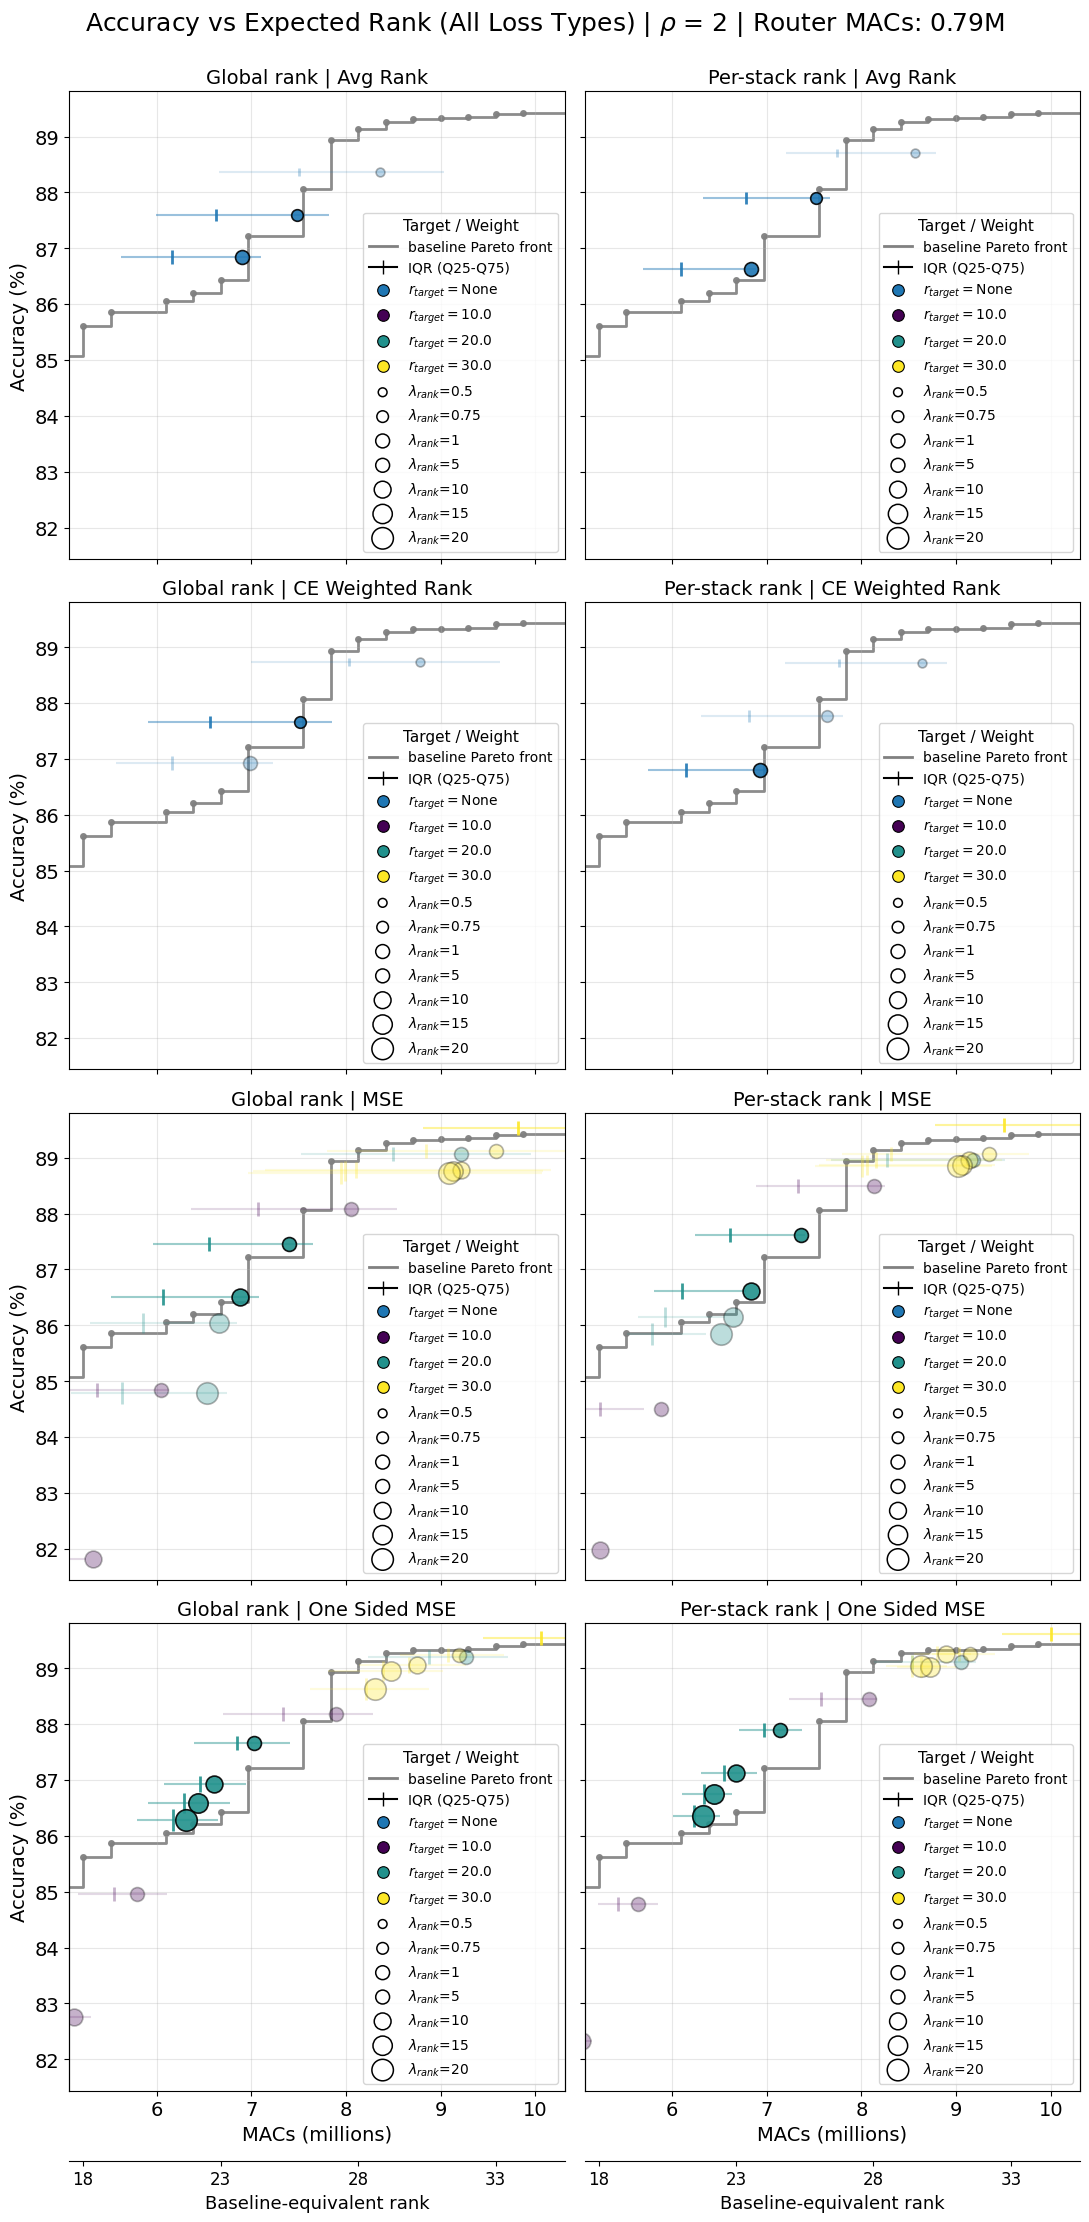

In [334]:
sweeps_for_plotting_4 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse', 'avg_rank', 'ce_weighted_rank'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [None, 10, 20, 30],
    pool_modes = ['subsample'],
    pool_reduction_factors = [POOL_REDUCTION_FACTOR],
    rank_loss_weights = [0.5,0.75,1, 5, 10, 15, 20]
)
fig, above_baseline_sweeps_all = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_4,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(18, 35),
    plot_title=f'Accuracy vs Expected Rank (All Loss Types){generate_title_postfix(MAX_RANK_CAP, POOL_REDUCTION_FACTOR)}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    fig_size_per_subplot=(5.5, 6.0)
    
 )
save_path = output_dir / f"all_relevant_loss_types_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')
print(f"Saved figure to: {save_path}")

sweeps_path = output_dir / f"all_relevant_sweeps_above_baseline_max_rank_cap_{MAX_RANK_CAP}.csv"
above_baseline_sweeps_all.to_csv(sweeps_path, index=False)

print(f"Saved figure to: {save_path}")
print(f"Saved above-baseline sweeps to: {sweeps_path}")
print(f"Number of above-baseline sweeps: {len(above_baseline_sweeps_all)}")


In [335]:
min_delta_acc = 0.2
router_modes_filter = None  # e.g. ["Per-stack"] or ["Global"]

pretty_df = make_df_pretty_(
    above_baseline_sweeps_all,
    router_modes=router_modes_filter,
)
pretty_df = pretty_df[np.round(pretty_df["delta acc"], 1) > min_delta_acc].reset_index(drop=True)

latex_table = make_latex_table_pretty_(
    above_baseline_sweeps_all,
    aggregate_best=True,
    min_delta_acc=min_delta_acc,
    router_modes=router_modes_filter,
)

display(pretty_df)
print(latex_table)

,loss type,router mode,ranks out,reduction factor,weight,target,rank baseline,mac dynamic,acc baseline,acc dyn,delta acc
0,one_sided_mse,Global,1,2,10.00,20.0,22.0,6.605585,86.204011,86.932447,0.728436
1,one_sided_mse,Per-stack,3,2,10.00,20.0,23.0,6.679329,86.424880,87.128092,0.703212
2,avg_rank,Per-stack,3,2,0.75,NaN,24.0,7.523330,87.216685,87.899594,0.682909
3,one_sided_mse,Per-stack,3,2,5.00,20.0,24.0,7.136962,87.216685,87.899594,0.682909
4,one_sided_mse,Per-stack,3,2,15.00,20.0,22.0,6.444234,86.204011,86.755260,0.551249
5,one_sided_mse,Global,1,2,5.00,20.0,24.0,7.031743,87.216685,87.655962,0.439276
6,ce_weighted_rank,Global,1,2,0.75,NaN,24.0,7.511947,87.216685,87.652270,0.435585
7,avg_rank,Global,1,2,1.00,NaN,23.0,6.900362,86.424880,86.836471,0.411591
8,batch_mean_mse,Per-stack,3,2,5.00,20.0,24.0,7.360304,87.216685,87.622739,0.406054
9,one_sided_mse,Global,1,2,15.00,20.0,22.0,6.435093,86.204011,86.596530,0.392519


\begin{tabular}{llcccccccc}
\toprule
Routing & Loss & $\rho$ & $\lambda_{\text{rank}}$ & $r_{\text{target}}$ & MACs (M) & Acc (\%) & BL. Rank Equiv & BL. acc (\%) & $\Delta$Acc \\
\midrule
\multirow{6}{*}{Global} & Avg Rank & 2 & 0.75 & - & 7.5 & 87.6 & 24 & 87.2 & +0.4 \\
 & Avg Rank & 2 & 1 & - & 6.9 & 86.8 & 23 & 86.4 & +0.4 \\
 & CE weighted rank & 2 & 0.75 & - & 7.5 & 87.7 & 24 & 87.2 & +0.4 \\
 & One-sided MSE & 2 & 5 & 20 & 7.0 & 87.7 & 24 & 87.2 & +0.4 \\
 & One-sided MSE & 2 & 10 & 20 & 6.6 & 86.9 & 22 & 86.2 & \textbf{\underline{+0.7}} \\
 & One-sided MSE & 2 & 15 & 20 & 6.4 & 86.6 & 22 & 86.2 & +0.4 \\
\midrule
\multirow{7}{*}{Per-stack} & Avg Rank & 2 & 0.75 & - & 7.5 & 87.9 & 24 & 87.2 & \textbf{\underline{+0.7}} \\
 & CE weighted rank & 2 & 1 & - & 6.9 & 86.8 & 23 & 86.4 & +0.4 \\
 & One-sided MSE & 2 & 5 & 20 & 7.1 & 87.9 & 24 & 87.2 & \textbf{\underline{+0.7}} \\
 & One-sided MSE & 2 & 10 & 20 & 6.7 & 87.1 & 23 & 86.4 & \textbf{\underline{+0.7}} \\
 & One-sided MSE & 2 

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/one_sided_mse_max_rank_cap_64_rf_2.png
Number of above-baseline sweeps (rf=2): 10
Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/one_sided_mse_max_rank_cap_64_rf_4.png
Number of above-baseline sweeps (rf=4): 12
Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/one_sided_mse_max_rank_cap_64_rf_6.png
Number of above-baseline sweeps (rf=6): 18
Saved filtered one-sided above-baseline sweeps to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/one_sided_mse_above_baseline_max_rank_cap_64.csv
Filtered one-sided sweeps count: 25


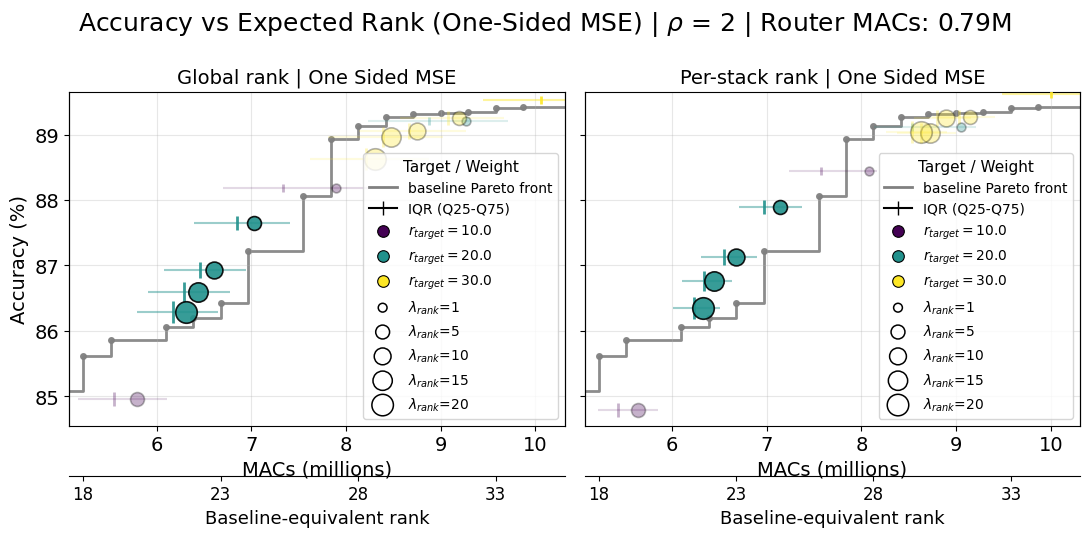

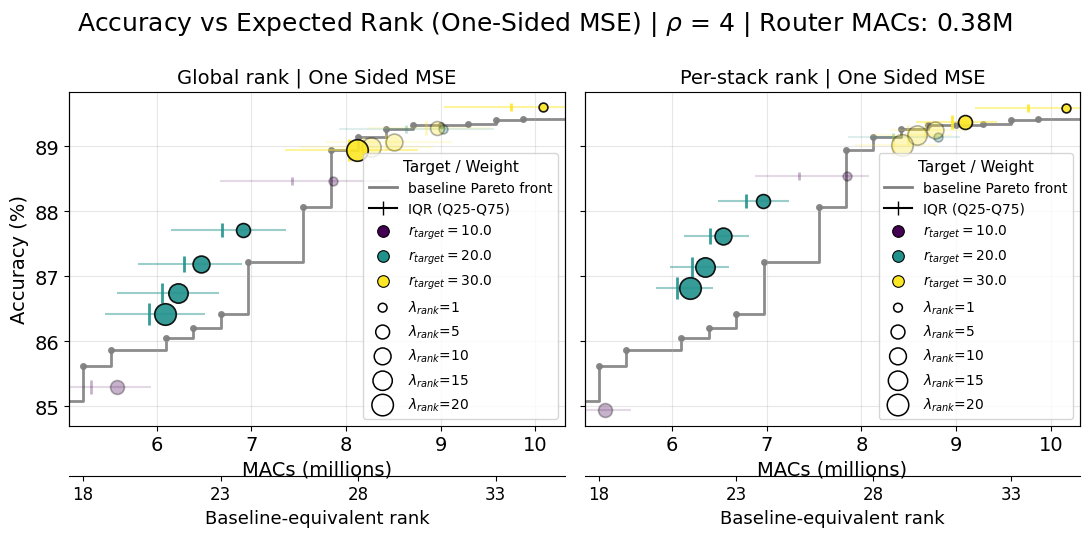

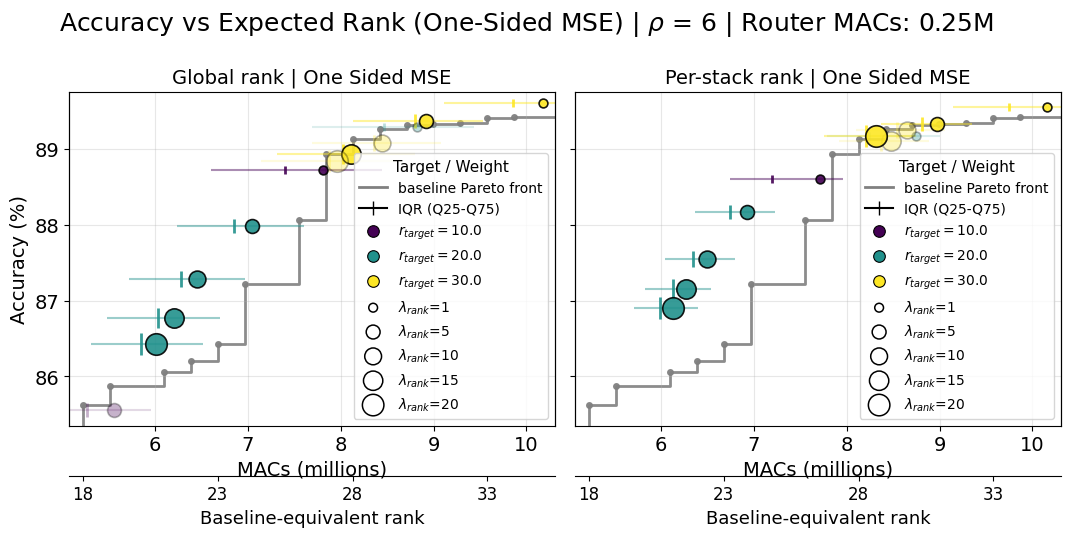

In [336]:
# all one-sided mse losses with different reduction factors:

above_baseline_one_sided_sweeps = []

for reduction_factor in [2, 4, 6]:

    sweeps_for_plotting_5 = filter_sweep_results(
        all_sweep_results,
        loss_types = ['one_sided_mse'],
        router_num_rank_outputs = [1, 3],
        rank_targets= [None, 10, 20, 30],
        pool_modes = ['subsample'],
        pool_reduction_factors = [reduction_factor],
        rank_loss_weights = [0.5,0.75,1, 5, 10, 15, 20]
    )
    fig, above_baseline_sweeps_temp = plot_rank_vs_acc_by_mode(
        sweeps_for_plotting_5,
        include_router_overhead=True,
        base_pareto_alpha=0.9,
        x_axis_cut_off_ranks=(18, 35),
        plot_title=f'Accuracy vs Expected Rank (One-Sided MSE){generate_title_postfix(MAX_RANK_CAP, reduction_factor)}',
        alpha_above_pareto=0.9,
        alpha_below_pareto=0.3,
        fig_size_per_subplot=(5.5, 6.0)
        
    )
    above_baseline_one_sided_sweeps.extend(above_baseline_sweeps_temp.to_dict(orient='records'))

    save_path = output_dir / f"one_sided_mse_max_rank_cap_{MAX_RANK_CAP}_rf_{reduction_factor}.png"
    fig.savefig(save_path, dpi=500, bbox_inches='tight')
    print(f"Saved figure to: {save_path}")
    print(f"Number of above-baseline sweeps (rf={reduction_factor}): {len(above_baseline_sweeps_temp)}")

# combine all above-baseline one-sided mse sweeps into a single DataFrame and save to CSV
above_baseline_one_sided_sweeps_df = pd.DataFrame(above_baseline_one_sided_sweeps)

# apply same delta-acc thresholding as the main table (display precision aware)
min_delta_acc_one_sided = globals().get("min_delta_acc", 0.2)
above_baseline_one_sided_sweeps_df["acc_minus_baseline_round"] = np.round(
    above_baseline_one_sided_sweeps_df["acc_minus_baseline"].astype(float),
    1,
 )
above_baseline_one_sided_sweeps_df = above_baseline_one_sided_sweeps_df[
    above_baseline_one_sided_sweeps_df["acc_minus_baseline_round"] > float(min_delta_acc_one_sided)
]
above_baseline_one_sided_sweeps_df = above_baseline_one_sided_sweeps_df.drop(columns=["acc_minus_baseline_round"]).reset_index(drop=True)

sweeps_path = output_dir / f"one_sided_mse_above_baseline_max_rank_cap_{MAX_RANK_CAP}.csv"
above_baseline_one_sided_sweeps_df.to_csv(sweeps_path, index=False)
print(f"Saved filtered one-sided above-baseline sweeps to: {sweeps_path}")
print(f"Filtered one-sided sweeps count: {len(above_baseline_one_sided_sweeps_df)}")

In [337]:
# format the combined one-sided mse sweeps into a pretty table and LaTeX table
min_delta_acc_one_sided = globals().get("min_delta_acc", 0.2)
router_modes_one_sided = ["Per-stack"]

pretty_df_one_sided = make_df_pretty_(
    above_baseline_one_sided_sweeps_df,
    router_modes=router_modes_one_sided,
)
pretty_df_one_sided = pretty_df_one_sided[
    np.round(pretty_df_one_sided["delta acc"], 1) > float(min_delta_acc_one_sided)
]

# keep target 20 only
pretty_df_one_sided = pretty_df_one_sided[pretty_df_one_sided["target"] == 20].reset_index(drop=True)

latex_table_one_sided = make_latex_table_pretty_(
    above_baseline_one_sided_sweeps_df,
    aggregate_best=True,
    min_delta_acc=min_delta_acc_one_sided,
    router_modes=router_modes_one_sided,
 )
display(pretty_df_one_sided)
print(latex_table_one_sided)

,loss type,router mode,ranks out,reduction factor,weight,target,rank baseline,mac dynamic,acc baseline,acc dyn,delta acc
0,one_sided_mse,Per-stack,3,6,5.0,20.0,23.0,6.926720,86.424880,88.169066,1.744186
1,one_sided_mse,Per-stack,3,4,5.0,20.0,23.0,6.962213,86.424880,88.157992,1.733112
2,one_sided_mse,Per-stack,3,4,10.0,20.0,22.0,6.537494,86.204011,87.626430,1.422419
3,one_sided_mse,Per-stack,3,6,10.0,20.0,22.0,6.498479,86.204011,87.552602,1.348591
4,one_sided_mse,Per-stack,3,6,15.0,20.0,21.0,6.268146,86.055740,87.150240,1.094500
5,one_sided_mse,Per-stack,3,4,15.0,20.0,21.0,6.347306,86.055740,87.146549,1.090808
6,one_sided_mse,Per-stack,3,6,20.0,20.0,21.0,6.136715,86.055740,86.906608,0.850867
7,one_sided_mse,Per-stack,3,4,20.0,20.0,21.0,6.190014,86.055740,86.814323,0.758583
8,one_sided_mse,Per-stack,3,2,10.0,20.0,23.0,6.679329,86.424880,87.128092,0.703212
9,one_sided_mse,Per-stack,3,2,5.0,20.0,24.0,7.136962,87.216685,87.899594,0.682909


\begin{tabular}{llcccccccc}
\toprule
Routing & Loss & $\rho$ & $\lambda_{\text{rank}}$ & $r_{\text{target}}$ & MACs (M) & Acc (\%) & BL. Rank Equiv & BL. acc (\%) & $\Delta$Acc \\
\midrule
\multirow{13}{*}{Per-stack} & One-sided MSE & 2 & 5 & 20 & 7.1 & 87.9 & 24 & 87.2 & +0.7 \\
 & One-sided MSE & 2 & 10 & 20 & 6.7 & 87.1 & 23 & 86.4 & +0.7 \\
 & One-sided MSE & 2 & 15 & 20 & 6.4 & 86.8 & 22 & 86.2 & +0.6 \\
 & One-sided MSE & 2 & 20 & 20 & 6.3 & 86.3 & 21 & 86.1 & +0.3 \\
 & One-sided MSE & 4 & 5 & 20 & 7.0 & 88.2 & 23 & 86.4 & \textbf{\underline{+1.7}} \\
 & One-sided MSE & 4 & 10 & 20 & 6.5 & 87.6 & 22 & 86.2 & +1.4 \\
 & One-sided MSE & 4 & 15 & 20 & 6.3 & 87.1 & 21 & 86.1 & +1.1 \\
 & One-sided MSE & 4 & 20 & 20 & 6.2 & 86.8 & 21 & 86.1 & +0.8 \\
 & One-sided MSE & 6 & 1 & 10 & 7.7 & 88.6 & 26 & 88.1 & +0.5 \\
 & One-sided MSE & 6 & 5 & 20 & 6.9 & 88.2 & 23 & 86.4 & \textbf{\underline{+1.7}} \\
 & One-sided MSE & 6 & 10 & 20 & 6.5 & 87.6 & 22 & 86.2 & +1.3 \\
 & One-sided MSE & 6

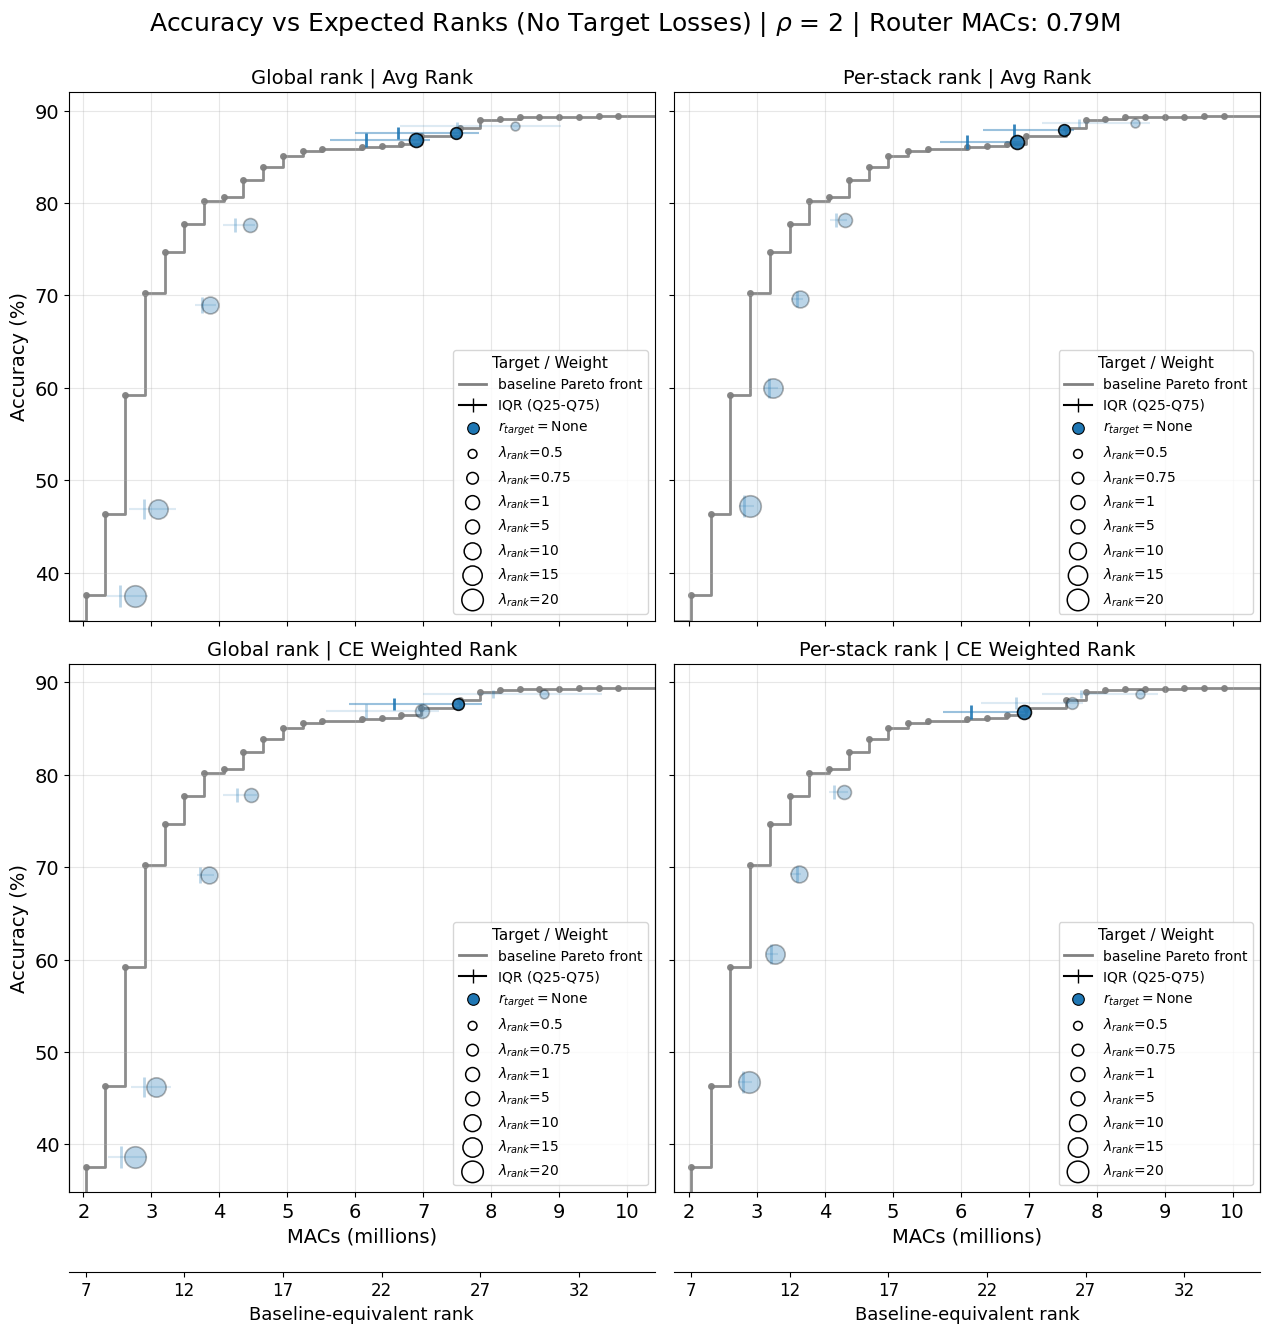

In [338]:
# loss functions with no rank target:
sweeps_for_plotting_2 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['avg_rank', 'ce_weighted_rank'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [None],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2],
    rank_loss_weights = [0.5,0.75,1, 5, 10, 15, 20]
)

fig, above_baseline_sweeps_no_target = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_2,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(7, 35),
    plot_title=f'Accuracy vs Expected Ranks (No Target Losses){generate_title_postfix(MAX_RANK_CAP, POOL_REDUCTION_FACTOR)}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / f"pareto_no_target_losses_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')

Saved figure to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/pareto_fixed_target_losses_max_rank_cap_64.png
Number of above-baseline sweeps: 16


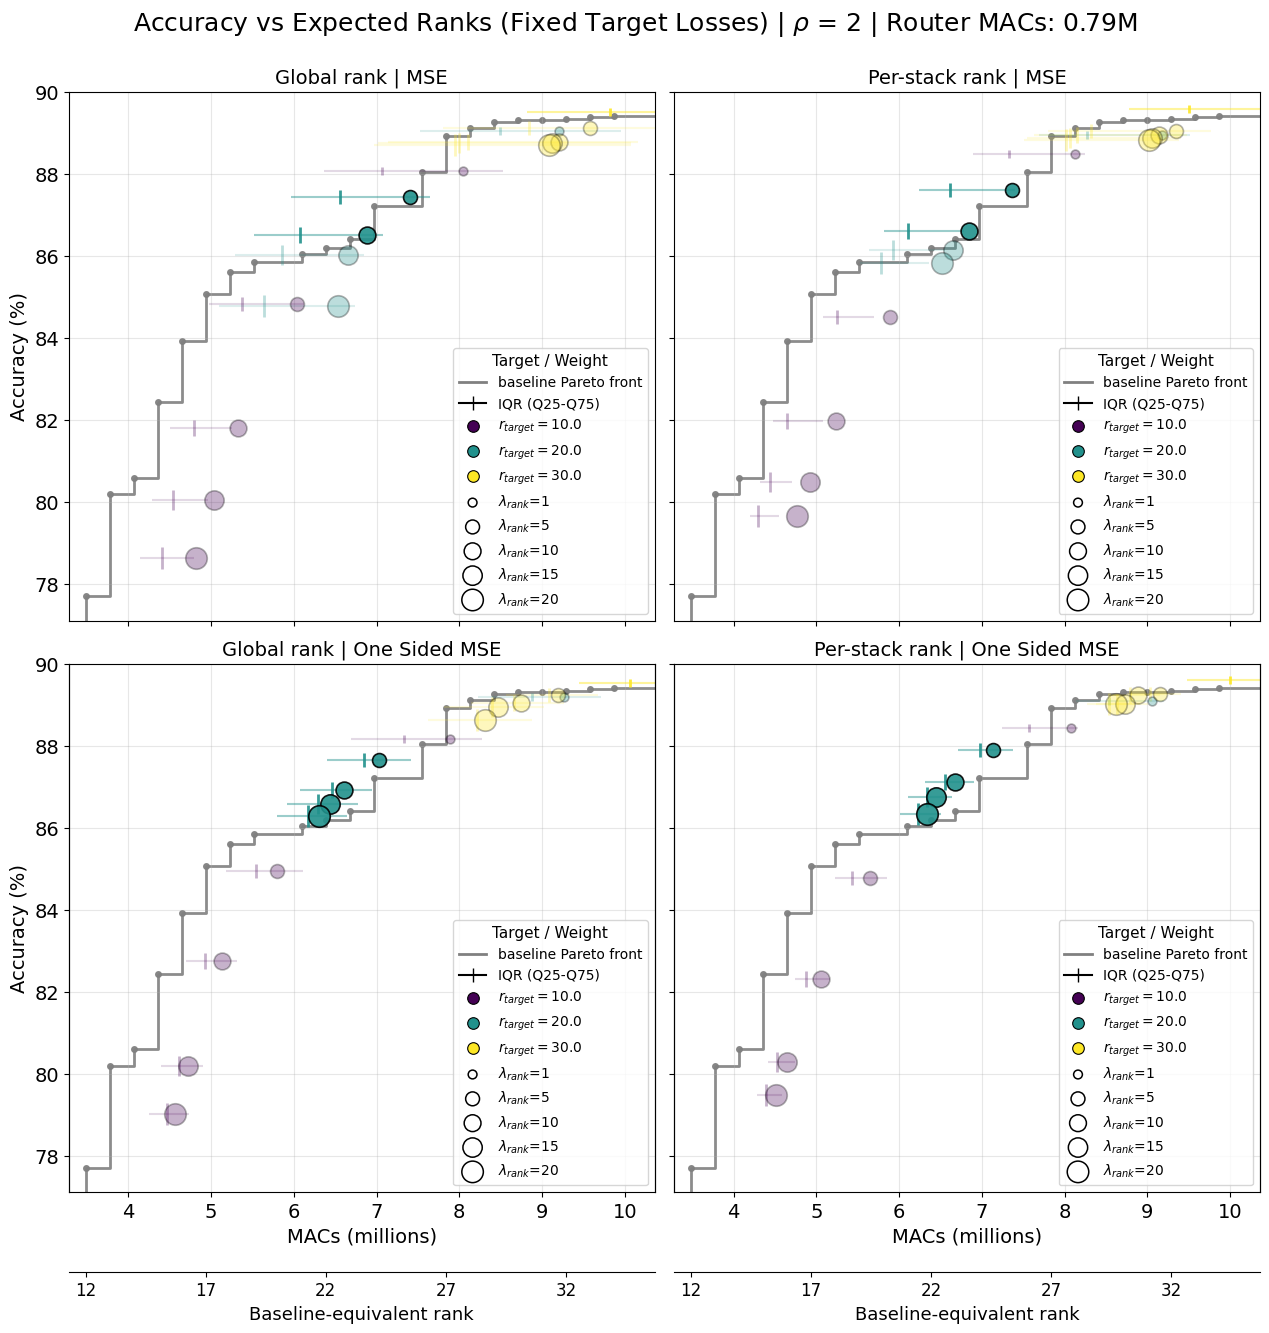

In [339]:
sweeps_for_plotting_3 = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs = [1, 3],
    rank_targets= [10, 20, 30],
    pool_modes = ['subsample'],
    pool_reduction_factors = [2]
)
fig, above_baseline_sweeps_fixed_target = plot_rank_vs_acc_by_mode(
    sweeps_for_plotting_3,
    include_router_overhead=True,
    base_pareto_alpha=0.9,
    x_axis_cut_off_ranks=(12, 35),
    plot_title=f'Accuracy vs Expected Ranks (Fixed Target Losses){generate_title_postfix(MAX_RANK_CAP, POOL_REDUCTION_FACTOR)}',
    alpha_above_pareto=0.9,
    alpha_below_pareto=0.3,
    
 )

save_path = output_dir / f"pareto_fixed_target_losses_max_rank_cap_{MAX_RANK_CAP}.png"
fig.savefig(save_path, dpi=500, bbox_inches='tight')


print(f"Saved figure to: {save_path}")
print(f"Number of above-baseline sweeps: {len(above_baseline_sweeps_fixed_target)}")

### Rank distrubution inspection

In [340]:
sweeps_for_distribution_global_rank = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs = [1],
    rank_targets= [None, 20],
    pool_modes = ['subsample'],
    pool_reduction_factors = [POOL_REDUCTION_FACTOR],
    rank_loss_weights = [0.75,5]
)

sweeps_for_distribution_per_stack_rank = filter_sweep_results(
    all_sweep_results,
    loss_types = ['batch_mean_mse', 'one_sided_mse'],
    router_num_rank_outputs = [3],
    rank_targets= [None, 20],
    pool_modes = ['subsample'],
    pool_reduction_factors = [POOL_REDUCTION_FACTOR],
    rank_loss_weights = [0.75,5]
)

# remove any that wasn't already filtered that doesn't have a path to the augmented per-sample df 
# (since we want to plot the rank distributions for those)
sweeps_for_distribution_plots_global_rank = [
    r for r in sweeps_for_distribution_global_rank
    if r["path_to_df_augmented"] is not None
]

sweeps_for_distribution_plots_per_stack_rank = [
    r for r in sweeps_for_distribution_per_stack_rank
    if r["path_to_df_augmented"] is not None
]

In [341]:
def build_rank_distribution_from_augmented_df(
    df_augmented: pd.DataFrame,
    over: str = "snr",
    normalize: bool = True,
    max_rank_cap: Optional[float] = None,
) -> pd.DataFrame:
    """
    Build rank-use distribution over SNR, class, or noise type from an augmented per-sample dataframe.

    Parameters
    ----------
    df_augmented : pd.DataFrame
        Augmented per-sample dataframe (typically per_sample_df_augmented_val.csv).
    over : str
        One of: 'snr', 'class', 'noise' (or direct column names: 'snr_eval', 'label', 'noise_type').
    normalize : bool
        If True, also return per-group fractions in a 'fraction' column.
    max_rank_cap : float or None
        Optional upper cap for rank values before building the distribution.

    Returns
    -------
    pd.DataFrame
        Columns: [group_column, 'rank_used', 'count'] and optionally ['fraction'].
    """

    axis_to_col = {
        "snr": "snr_eval",
        "class": "label",
        "noise": "noise_type",
        "snr_eval": "snr_eval",
        "label": "label",
        "noise_type": "noise_type",
    }
    if over not in axis_to_col:
        raise ValueError("over must be one of: 'snr', 'class', 'noise', 'snr_eval', 'label', 'noise_type'")

    group_col = axis_to_col[over]
    if group_col not in df_augmented.columns:
        raise ValueError(f"Column '{group_col}' not found in augmented dataframe")

    rank_col = "rank" if "rank" in df_augmented.columns else "rank_used"
    if rank_col not in df_augmented.columns:
        raise ValueError("Neither 'rank' nor 'rank_used' found in augmented dataframe")

    def _cap_rank(v: float) -> float:
        if max_rank_cap is None:
            return float(v)
        return float(min(max_rank_cap, float(v)))

    def _rank_to_list(value: Any) -> List[float]:
        if pd.isna(value):
            return []

        if isinstance(value, str):
            value = value.strip()
            if value.startswith("[") and value.endswith("]"):
                value = json.loads(value)

        if isinstance(value, np.ndarray):
            value = value.tolist()

        if isinstance(value, (list, tuple)):
            out = []
            for v in value:
                if pd.isna(v):
                    continue
                out.append(_cap_rank(float(v)))
            return out

        return [_cap_rank(float(value))]

    dist_df = df_augmented[[group_col, rank_col]].copy()
    dist_df["rank_used"] = dist_df[rank_col].map(_rank_to_list)
    dist_df = dist_df.explode("rank_used")
    dist_df = dist_df.dropna(subset=["rank_used"]).copy()

    # Keep integer-like rank values as ints for cleaner grouping/plot labels.
    dist_df["rank_used"] = dist_df["rank_used"].astype(float).round().astype(int)

    distribution = (
        dist_df.groupby([group_col, "rank_used"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
        .sort_values([group_col, "rank_used"])
        .reset_index(drop=True)
    )

    if normalize:
        distribution["fraction"] = distribution["count"] / distribution.groupby(group_col)["count"].transform("sum")

    return distribution

In [342]:
def plot_smoothed_rank_histograms(
    distributions: List[pd.DataFrame] | pd.DataFrame,
    over: str = "snr",
    model_labels: Optional[List[str]] = None,
    use_fraction: bool = True,
    smooth_window: int = 5,
    figsize_per_row: Tuple[float, float] = (10, 1.35),
    fill_alpha: float = 0.0,
    show_mean_rank: bool = True,
    annotate_mean_rank_values: bool = True,
    test_mean_difference: bool = True,
    paired_differences_by_group: Optional[Dict[Any, np.ndarray]] = None,
    model_accuracy_by_group: Optional[List[Dict[Any, float]]] = None,
    show_accuracy_annotation: bool = True,
    mcnemar_by_group: Optional[Dict[Any, Dict[str, float]]] = None,
    show_mcnemar_annotation: bool = True,
    show_iqr_annotation: bool = True,
    ci_level: float = 0.95,
    n_bootstrap: int = 10000,
    random_seed: int = 0,
):
    """
    Plot smoothed rank histograms with one row per group (SNR/class/noise),
    and multiple model setups overlaid in each row.

    Statistical test (when enabled): paired bootstrap CI on mean difference
    of per-sample rank deltas d = rank_model_1 - rank_model_2.
    """

    # Backward compatibility: allow a single dataframe.
    if isinstance(distributions, pd.DataFrame):
        distributions = [distributions]

    if len(distributions) == 0:
        raise ValueError("distributions must contain at least one DataFrame")
    if len(distributions) > 2:
        raise ValueError("At most two distributions can be plotted at once")

    axis_to_col = {
        "snr": "snr_eval",
        "class": "label",
        "noise": "noise_type",
    }
    if over not in axis_to_col:
        raise ValueError("over must be one of: 'snr', 'class', 'noise'")

    group_col = axis_to_col[over]
    value_col = "fraction" if use_fraction else "count"

    if model_labels is None:
        model_labels = [f"Model {i+1}" for i in range(len(distributions))]
    if len(model_labels) != len(distributions):
        raise ValueError("Length of model_labels must match number of distributions")
    if model_accuracy_by_group is not None and len(model_accuracy_by_group) != len(distributions):
        raise ValueError("Length of model_accuracy_by_group must match number of distributions")

    # Build pivots per model
    pivots = []
    all_groups = set()
    all_ranks = set()

    for dist_df in distributions:
        if value_col not in dist_df.columns:
            raise ValueError(
                f"Column '{value_col}' not found. Build distribution with normalize=True for fraction plots."
            )

        pivot_df = dist_df.pivot_table(
            index=group_col,
            columns="rank_used",
            values=value_col,
            fill_value=0.0,
            aggfunc="sum",
        )

        pivots.append(pivot_df)
        all_groups.update(pivot_df.index.tolist())
        all_ranks.update(pivot_df.columns.tolist())

    # Sort groups for readability
    if over == "snr":
        def _snr_sort_key(v: Any) -> float:
            if isinstance(v, str) and v.lower() == "inf":
                return float("inf")
            return float(v)
        groups_sorted = sorted(all_groups, key=_snr_sort_key)
    else:
        groups_sorted = sorted(all_groups)

    ranks_sorted = sorted(all_ranks)
    ranks = np.array(ranks_sorted, dtype=float)
    n_rows = len(groups_sorted)

    fig_height = max(3.2, figsize_per_row[1] * n_rows + 1.8)
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(figsize_per_row[0], fig_height),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    axes = axes.flatten()

    w = int(max(1, smooth_window))
    kernel = np.ones(w) / w

    # Precompute all smoothed curves and means to enforce shared y-limits
    smoothed_by_model = []
    mean_rank_by_model = []
    prob_lt_mean_by_model = []
    q25_rank_by_model = []
    q75_rank_by_model = []
    global_y_max = 0.0

    for pivot_df in pivots:
        pivot_aligned = pivot_df.reindex(index=groups_sorted, columns=ranks_sorted, fill_value=0.0)

        curves = []
        means = []
        probs_lt_mean = []
        q25_ranks = []
        q75_ranks = []
        for _, row in pivot_aligned.iterrows():
            y = row.to_numpy(dtype=float)
            y_smooth = np.convolve(y, kernel, mode="same") if w > 1 else y
            curves.append(y_smooth)
            if len(y_smooth) > 0:
                global_y_max = max(global_y_max, float(np.max(y_smooth)))

            total_mass = float(np.sum(y))
            if total_mass > 0:
                mean_rank = float(np.dot(ranks, y) / total_mass)
                means.append(mean_rank)
                probs_lt_mean.append(float(np.sum(y[ranks < mean_rank]) / total_mass))
                cdf = np.cumsum(y) / total_mass
                q25_ranks.append(float(np.interp(0.25, cdf, ranks)))
                q75_ranks.append(float(np.interp(0.75, cdf, ranks)))
            else:
                means.append(np.nan)
                probs_lt_mean.append(np.nan)
                q25_ranks.append(np.nan)
                q75_ranks.append(np.nan)

        smoothed_by_model.append(curves)
        mean_rank_by_model.append(means)
        prob_lt_mean_by_model.append(probs_lt_mean)
        q25_rank_by_model.append(q25_ranks)
        q75_rank_by_model.append(q75_ranks)

    statistical_tests = []
    if test_mean_difference:
        if len(distributions) != 2:
            raise ValueError("Mean-difference test requires exactly two distributions")
        if paired_differences_by_group is None:
            raise ValueError("paired_differences_by_group is required for paired bootstrap CI testing")

        rng = np.random.default_rng(random_seed)
        alpha = 1.0 - float(ci_level)

        for row_idx, group_value in enumerate(groups_sorted):
            d = np.asarray(paired_differences_by_group.get(group_value, []), dtype=float)
            d = d[np.isfinite(d)]

            if len(d) == 0:
                mean_diff = np.nan
                ci_low = np.nan
                ci_high = np.nan
                significant = False
            else:
                boot_idx = rng.integers(0, len(d), size=(int(max(1, n_bootstrap)), len(d)))
                boot_means = d[boot_idx].mean(axis=1)
                mean_diff = float(np.mean(d))
                ci_low = float(np.quantile(boot_means, alpha / 2.0))
                ci_high = float(np.quantile(boot_means, 1.0 - alpha / 2.0))
                significant = bool((ci_low > 0) or (ci_high < 0))

            statistical_tests.append(
                {
                    group_col: group_value,
                    "model_1": model_labels[0],
                    "model_2": model_labels[1],
                    "mean_1": mean_rank_by_model[0][row_idx],
                    "mean_2": mean_rank_by_model[1][row_idx],
                    "mean_diff": mean_diff,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "ci_level": ci_level,
                    "significant": significant,
                    "n_pairs": int(len(d)),
                }
            )
    if mcnemar_by_group is not None and statistical_tests:
        for row in statistical_tests:
            g = row[group_col]
            mcn = mcnemar_by_group.get(g)
            if mcn is None:
                continue
            row["mcnemar_p"] = mcn.get("p_value", np.nan)
            row["mcnemar_p_ci_low"] = mcn.get("p_ci_low", np.nan)
            row["mcnemar_p_ci_high"] = mcn.get("p_ci_high", np.nan)
            row["mcnemar_significant"] = mcn.get("significant", False)
            row["n01"] = mcn.get("n01", np.nan)
            row["n10"] = mcn.get("n10", np.nan)

    if use_fraction:
        y_top = max(global_y_max * 1.08, 0.01)
    else:
        y_top = max(global_y_max * 1.08, 1.0)

    # Colorblind-friendly, high-contrast palette + linestyle cycling
    colors = [
        "#0072B2",  # blue
        "#D55E00",  # vermillion
        "#009E73",  # bluish green
        "#CC79A7",  # reddish purple
        "#E69F00",  # orange
        "#56B4E9",  # sky blue
        "#000000",  # black
        "#F0E442",  # yellow
    ]
    line_styles = ["-", "--", "-.", ":"]

    from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, VPacker, TextArea

    for row_idx, group_value in enumerate(groups_sorted):
        ax = axes[row_idx]
        row_mean_items = []
        row_prob_items = []
        row_iqr_items = []

        for model_idx, label in enumerate(model_labels):
            y_smooth = smoothed_by_model[model_idx][row_idx]
            mean_rank = mean_rank_by_model[model_idx][row_idx]
            prob_lt_mean = prob_lt_mean_by_model[model_idx][row_idx]
            q25_rank = q25_rank_by_model[model_idx][row_idx]
            q75_rank = q75_rank_by_model[model_idx][row_idx]
            color = colors[model_idx % len(colors)]
            line_style = line_styles[(model_idx // len(colors)) % len(line_styles)]

            ax.plot(
                ranks,
                y_smooth,
                linewidth=2.2,
                color=color,
                linestyle=line_style,
                label=label,
            )
            if fill_alpha > 0:
                ax.fill_between(ranks, y_smooth, alpha=fill_alpha, color=color)

            if show_mean_rank and np.isfinite(mean_rank):
                ax.axvline(
                    mean_rank,
                    color=color,
                    linestyle=":",
                    linewidth=1.4,
                    alpha=0.85,
                )

            if np.isfinite(mean_rank):
                row_mean_items.append((f"μ{model_idx + 1}={mean_rank:.2f}", color))
            if np.isfinite(prob_lt_mean):
                row_prob_items.append((f"P(r<μ{model_idx + 1})={prob_lt_mean:.1%}", color))
            if show_iqr_annotation and np.isfinite(q25_rank) and np.isfinite(q75_rank):
                row_iqr_items.append((f"IQR{model_idx + 1}=[{q25_rank:.2f},{q75_rank:.2f}]", color))

        if annotate_mean_rank_values and row_mean_items:
            parts = []
            for i, (mean_text, mean_color) in enumerate(row_mean_items):
                parts.append(TextArea(mean_text, textprops={"fontsize": 10, "color": mean_color, "alpha": 0.95}))
                if i < len(row_mean_items) - 1:
                    parts.append(TextArea(" | ", textprops={"fontsize": 10, "color": "black", "alpha": 0.9}))

            if test_mean_difference and len(statistical_tests) == len(groups_sorted):
                stat_row = statistical_tests[row_idx]
                lo = stat_row["ci_low"]
                hi = stat_row["ci_high"]
                if np.isfinite(lo) and np.isfinite(hi):
                    sig_text = "sig" if stat_row["significant"] else "n.s."
                    ci_text = f"Δ={stat_row['mean_diff']:.2f}, CI=[{lo:.2f},{hi:.2f}] ({sig_text})"
                else:
                    ci_text = "Δ/CI unavailable"
                parts.append(TextArea(" | ", textprops={"fontsize": 10, "color": "black", "alpha": 0.9}))
                parts.append(TextArea(ci_text, textprops={"fontsize": 10, "color": "black", "alpha": 0.95}))

            top_line = HPacker(children=parts, align="center", pad=0, sep=0)

            block_rows = [top_line]
            if row_prob_items:
                prob_parts = []
                for i, (prob_text, prob_color) in enumerate(row_prob_items):
                    prob_parts.append(TextArea(prob_text, textprops={"fontsize": 10, "color": prob_color, "alpha": 0.95}))
                    if i < len(row_prob_items) - 1:
                        prob_parts.append(TextArea(" | ", textprops={"fontsize": 10, "color": "black", "alpha": 0.9}))
                prob_line = HPacker(children=prob_parts, align="center", pad=0, sep=0)
                block_rows.append(prob_line)
            if row_iqr_items:
                iqr_parts = []
                for i, (iqr_text, iqr_color) in enumerate(row_iqr_items):
                    iqr_parts.append(TextArea(iqr_text, textprops={"fontsize": 10, "color": iqr_color, "alpha": 0.95}))
                    if i < len(row_iqr_items) - 1:
                        iqr_parts.append(TextArea(" | ", textprops={"fontsize": 10, "color": "black", "alpha": 0.9}))
                iqr_line = HPacker(children=iqr_parts, align="center", pad=0, sep=0)
                block_rows.append(iqr_line)
            if show_accuracy_annotation and model_accuracy_by_group is not None:
                acc_parts = []
                for model_idx, _ in enumerate(model_labels):
                    acc_map = model_accuracy_by_group[model_idx] if model_idx < len(model_accuracy_by_group) else {}
                    acc_val = acc_map.get(group_value, np.nan)
                    if np.isfinite(acc_val):
                        acc_color = colors[model_idx % len(colors)]
                        acc_parts.append(TextArea(f"acc{model_idx + 1}={float(acc_val):.2f}%", textprops={"fontsize": 10, "color": acc_color, "alpha": 0.95}))
                        if model_idx < len(model_labels) - 1:
                            acc_parts.append(TextArea(" | ", textprops={"fontsize": 10, "color": "black", "alpha": 0.9}))

                if acc_parts:
                    acc_line = HPacker(children=acc_parts, align="center", pad=0, sep=0)
                    block_rows.append(acc_line)
            if show_mcnemar_annotation and mcnemar_by_group is not None:
                mcn = mcnemar_by_group.get(group_value)
                if mcn is not None:
                    p_val = mcn.get("p_value", np.nan)
                    p_lo = mcn.get("p_ci_low", np.nan)
                    p_hi = mcn.get("p_ci_high", np.nan)
                    sig_text = "sig" if bool(mcn.get("significant", False)) else "n.s."
                    if np.isfinite(p_val) and np.isfinite(p_lo) and np.isfinite(p_hi):
                        mcn_text = f"McN p={p_val:.3g}, CI=[{p_lo:.3g},{p_hi:.3g}] ({sig_text})"
                    elif np.isfinite(p_val):
                        mcn_text = f"McN p={p_val:.3g} ({sig_text})"
                    else:
                        mcn_text = "McN unavailable"
                    mcn_line = TextArea(mcn_text, textprops={"fontsize": 10, "color": "black", "alpha": 0.95})
                    block_rows.append(mcn_line)

            packed_text = VPacker(children=block_rows, align="right", pad=0, sep=3) if len(block_rows) > 1 else top_line
            anchored = AnchoredOffsetbox(
                loc="upper right",
                child=packed_text,
                frameon=False,
                pad=0.0,
                borderpad=0.0,
                bbox_to_anchor=(0.995, 0.90),
                bbox_transform=ax.transAxes,
            )
            ax.add_artist(anchored)

        if over == "snr":
            group_text = f"SNR: {group_value}"
        else:
            group_text = str(group_value)
        ax.set_ylabel("")
        ax.text(
            0.01,
            0.95,
            group_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            clip_on=True,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "0.5",
                "alpha": 0.9,
            },
        )
        ax.grid(True, axis="y", linestyle="-", alpha=0.25)
        ax.set_ylim(0.0 if use_fraction else 0, y_top)

    title_name_map = {
        "snr_eval": "SNR",
        "label": "Class",
        "noise_type": "Noise type",
    }
    title_group_name = title_name_map.get(group_col, str(group_col))

    title_text = f"Smoothed rank distribution over {title_group_name}"
    if test_mean_difference:
        title_text += f" | paired bootstrap {int(ci_level*100)}% CI"
    fig.suptitle(title_text, fontsize=17, y=0.97)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    if show_mean_rank:
        handles = handles + [plt.Line2D([0], [0], linestyle=":", linewidth=1.4, color="gray")]
        legend_labels = legend_labels + ["mean rank"]

    legend_ncol = 2 if len(legend_labels) > 2 else 1
    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        borderaxespad=0.0,
        ncol=legend_ncol,
        fontsize=10,
        frameon=True,
    )

    axes[-1].set_xlabel("rank_used")

    # avoid overcrowded x ticks
    tick_step = max(1, len(ranks) // 20)
    axes[-1].set_xticks(ranks[::tick_step])
    axes[-1].set_xticklabels([str(int(r)) for r in ranks[::tick_step]], rotation=45, ha="right")

    mean_tables = []
    for model_idx, label in enumerate(model_labels):
        mean_tables.append(pd.DataFrame({
            group_col: groups_sorted,
            "model_label": label,
            "mean_rank": mean_rank_by_model[model_idx],
        }))

    prob_tables = []
    for model_idx, label in enumerate(model_labels):
        prob_tables.append(pd.DataFrame({
            group_col: groups_sorted,
            "model_label": label,
            "p_rank_lt_mean": prob_lt_mean_by_model[model_idx],
        }))

    iqr_tables = []
    for model_idx, label in enumerate(model_labels):
        iqr_tables.append(pd.DataFrame({
            group_col: groups_sorted,
            "model_label": label,
            "q25_rank": q25_rank_by_model[model_idx],
            "q75_rank": q75_rank_by_model[model_idx],
            "iqr": np.array(q75_rank_by_model[model_idx]) - np.array(q25_rank_by_model[model_idx]),
        }))

    statistical_tests_df = pd.DataFrame(statistical_tests)

    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.91])
    return fig, axes, {
        "groups": groups_sorted,
        "ranks": ranks_sorted,
        "pivots": pivots,
        "mean_ranks": mean_rank_by_model,
        "mean_tables": mean_tables,
        "prob_lt_mean": prob_lt_mean_by_model,
        "prob_tables": prob_tables,
        "q25_rank": q25_rank_by_model,
        "q75_rank": q75_rank_by_model,
        "iqr_tables": iqr_tables,
        "statistical_tests": statistical_tests_df,
    }

In [343]:
def _rank_value_to_scalar(value: Any, max_rank_cap: Optional[float] = None) -> float:
    if pd.isna(value):
        return np.nan

    def _cap(v: float) -> float:
        if max_rank_cap is None:
            return float(v)
        return float(min(max_rank_cap, float(v)))

    if isinstance(value, str):
        value = value.strip()
        if value.startswith("[") and value.endswith("]"):
            value = json.loads(value)

    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, (list, tuple)):
        vals = [float(v) for v in value if not pd.isna(v)]
        if len(vals) == 0:
            return np.nan
        vals = [_cap(v) for v in vals]
        return float(np.mean(vals))

    return _cap(float(value))


def compute_paired_rank_differences_by_group(
    df_model_1: pd.DataFrame,
    df_model_2: pd.DataFrame,
    over: str,
    max_rank_cap: Optional[float] = None,
) -> Dict[Any, np.ndarray]:
    axis_to_col = {
        "snr": "snr_eval",
        "class": "label",
        "noise": "noise_type",
    }
    if over not in axis_to_col:
        raise ValueError("over must be one of: 'snr', 'class', 'noise'")

    group_col = axis_to_col[over]
    if group_col not in df_model_1.columns or group_col not in df_model_2.columns:
        raise ValueError(f"Group column '{group_col}' missing in one of the model dataframes")

    rank_col_1 = "rank" if "rank" in df_model_1.columns else "rank_used"
    rank_col_2 = "rank" if "rank" in df_model_2.columns else "rank_used"
    if rank_col_1 not in df_model_1.columns or rank_col_2 not in df_model_2.columns:
        raise ValueError("Could not find rank/rank_used in one of the model dataframes")

    key_candidates = ["id", "val_set_id", "label", "snr_eval", "noise_type"]
    pair_keys = [k for k in key_candidates if k in df_model_1.columns and k in df_model_2.columns]

    if group_col not in pair_keys:
        merge_keys = pair_keys + [group_col]
    else:
        merge_keys = pair_keys

    if len(merge_keys) == 0:
        raise ValueError("No shared pairing keys found between model dataframes")

    left = df_model_1[merge_keys + [rank_col_1]].copy()
    right = df_model_2[merge_keys + [rank_col_2]].copy()

    left["rank_scalar_1"] = left[rank_col_1].map(lambda v: _rank_value_to_scalar(v, max_rank_cap=max_rank_cap))
    right["rank_scalar_2"] = right[rank_col_2].map(lambda v: _rank_value_to_scalar(v, max_rank_cap=max_rank_cap))

    left = (
        left[merge_keys + ["rank_scalar_1"]]
        .dropna(subset=["rank_scalar_1"])
        .groupby(merge_keys, as_index=False)["rank_scalar_1"]
        .mean()
    )
    right = (
        right[merge_keys + ["rank_scalar_2"]]
        .dropna(subset=["rank_scalar_2"])
        .groupby(merge_keys, as_index=False)["rank_scalar_2"]
        .mean()
    )

    merged = pd.merge(left, right, on=merge_keys, how="inner")
    if merged.empty:
        raise ValueError("No paired rows found between the two model dataframes")

    merged["rank_diff"] = merged["rank_scalar_1"] - merged["rank_scalar_2"]

    if group_col not in merged.columns:
        raise ValueError(f"Group column '{group_col}' missing after merge")

    return {
        g: grp["rank_diff"].to_numpy(dtype=float)
        for g, grp in merged.groupby(group_col)
    }


def compute_group_accuracy_map(
    df_augmented: pd.DataFrame,
    over: str,
) -> Dict[Any, float]:
    axis_to_col = {
        "snr": "snr_eval",
        "class": "label",
        "noise": "noise_type",
    }
    if over not in axis_to_col:
        raise ValueError("over must be one of: 'snr', 'class', 'noise'")

    group_col = axis_to_col[over]
    if group_col not in df_augmented.columns:
        return {}

    if "correct" in df_augmented.columns:
        s = df_augmented.groupby(group_col)["correct"].mean() * 100.0
        return {k: float(v) for k, v in s.items()}

    if "acc" in df_augmented.columns:
        s = df_augmented.groupby(group_col)["acc"].mean()
        if float(s.max()) <= 1.0:
            s = s * 100.0
        return {k: float(v) for k, v in s.items()}

    return {}


def compute_bootstrapped_mcnemar_by_group(
    df_model_1: pd.DataFrame,
    df_model_2: pd.DataFrame,
    over: str,
    n_bootstrap: int = 10000,
    alpha: float = 0.05,
    random_seed: int = 0,
) -> Dict[Any, Dict[str, float]]:
    from scipy.stats import binomtest

    axis_to_col = {
        "snr": "snr_eval",
        "class": "label",
        "noise": "noise_type",
    }
    if over not in axis_to_col:
        raise ValueError("over must be one of: 'snr', 'class', 'noise'")

    group_col = axis_to_col[over]
    if group_col not in df_model_1.columns or group_col not in df_model_2.columns:
        raise ValueError(f"Group column '{group_col}' missing in one of the model dataframes")

    if "correct" not in df_model_1.columns or "correct" not in df_model_2.columns:
        raise ValueError("McNemar requires per-sample 'correct' column in both model dataframes")

    key_candidates = ["id", "val_set_id", "label", "snr_eval", "noise_type"]
    pair_keys = [k for k in key_candidates if k in df_model_1.columns and k in df_model_2.columns]
    if group_col not in pair_keys:
        merge_keys = pair_keys + [group_col]
    else:
        merge_keys = pair_keys

    if len(merge_keys) == 0:
        raise ValueError("No shared pairing keys found between model dataframes")

    left = df_model_1[merge_keys + ["correct"]].copy()
    right = df_model_2[merge_keys + ["correct"]].copy()

    left["correct_1"] = left["correct"].astype(float)
    right["correct_2"] = right["correct"].astype(float)

    left = (
        left[merge_keys + ["correct_1"]]
        .dropna(subset=["correct_1"])
        .groupby(merge_keys, as_index=False)["correct_1"]
        .mean()
    )
    right = (
        right[merge_keys + ["correct_2"]]
        .dropna(subset=["correct_2"])
        .groupby(merge_keys, as_index=False)["correct_2"]
        .mean()
    )

    merged = pd.merge(left, right, on=merge_keys, how="inner")
    if merged.empty:
        raise ValueError("No paired rows found between the two model dataframes for McNemar")

    merged["correct_1"] = (merged["correct_1"] >= 0.5).astype(int)
    merged["correct_2"] = (merged["correct_2"] >= 0.5).astype(int)

    rng = np.random.default_rng(random_seed)
    out: Dict[Any, Dict[str, float]] = {}

    for g, grp in merged.groupby(group_col):
        c1 = grp["correct_1"].to_numpy(dtype=int)
        c2 = grp["correct_2"].to_numpy(dtype=int)

        n10 = int(np.sum((c1 == 1) & (c2 == 0)))
        n01 = int(np.sum((c1 == 0) & (c2 == 1)))
        n_disc = n10 + n01

        if n_disc == 0:
            p_value = 1.0
        else:
            p_value = float(binomtest(min(n10, n01), n_disc, 0.5, alternative="two-sided").pvalue)

        n = len(c1)
        boot_p = np.empty(int(max(1, n_bootstrap)), dtype=float)
        for b in range(len(boot_p)):
            idx = rng.integers(0, n, size=n)
            c1b = c1[idx]
            c2b = c2[idx]
            n10b = int(np.sum((c1b == 1) & (c2b == 0)))
            n01b = int(np.sum((c1b == 0) & (c2b == 1)))
            n_disc_b = n10b + n01b
            if n_disc_b == 0:
                boot_p[b] = 1.0
            else:
                boot_p[b] = float(binomtest(min(n10b, n01b), n_disc_b, 0.5, alternative="two-sided").pvalue)

        p_ci_low = float(np.quantile(boot_p, alpha / 2.0))
        p_ci_high = float(np.quantile(boot_p, 1.0 - alpha / 2.0))

        out[g] = {
            "p_value": p_value,
            "p_ci_low": p_ci_low,
            "p_ci_high": p_ci_high,
            "significant": bool(p_value < alpha),
            "n01": float(n01),
            "n10": float(n10),
        }

    return out


def plot_distributions_for_sweeps(
    sweeps: List[Dict[str, Any]],
    title_prefix: str,
    smooth_window: int = 5,
    max_rank_cap: Optional[float] = None,
    n_bootstrap: int = 10000,
    random_seed: int = 0,
    mcnemar_alpha: float = 0.05,
    show_accuracy_annotation: bool = True,
    show_mcnemar_annotation: bool = True,
    show_iqr_annotation: bool = True,
    save_figures: bool = True,
    save_dir: Optional[Union[str, Path]] = None,
) -> Dict[str, Any]:
    """
    Build and plot smoothed rank distributions (SNR/class/noise) for a list of sweeps.

    Returns a dict with labels, distribution tables and figures.
    """
    if not sweeps:
        raise ValueError(f"No sweeps provided for: {title_prefix}")
    if len(sweeps) > 2:
        raise ValueError(
            f"This visualization supports at most 2 sweeps at a time for statistical testing, got {len(sweeps)}"
        )

    labels: List[str] = []
    dist_snr: List[pd.DataFrame] = []
    dist_class: List[pd.DataFrame] = []
    dist_noise: List[pd.DataFrame] = []
    augmented_dfs: List[pd.DataFrame] = []
    acc_by_group_snr: List[Dict[Any, float]] = []
    acc_by_group_class: List[Dict[Any, float]] = []
    acc_by_group_noise: List[Dict[Any, float]] = []

    pretty_loss_name = {
        "one_sided_mse": "One-sided MSE",
        "batch_mean_mse": "MSE",
        "avg_rank": "Avg Rank",
        "ce_weighted_rank": "CE Weighted Rank",
    }

    for r in sweeps:
        aug_path = r.get("path_to_df_augmented")
        if aug_path is None:
            continue

        df_aug = pd.read_csv(Path(aug_path))

        loss_name = pretty_loss_name.get(r['rank_loss_mode'], r['rank_loss_mode'])
        rank_mode_label = {1: "Global Rank", 3: "Pr-Stack Rank"}.get(
            r['num_rank_outputs'],
            f"out={r['num_rank_outputs']}"
        )
        lbl = (
            f"{loss_name} | {rank_mode_label} | "
            f"target={r['rank_target']} | w={r['rank_loss_weight']} | "
            f"$\\rho$={r['pool_reduction_factor']}"
        )
        labels.append(lbl)
        augmented_dfs.append(df_aug)
        acc_by_group_snr.append(compute_group_accuracy_map(df_aug, over="snr"))
        acc_by_group_class.append(compute_group_accuracy_map(df_aug, over="class"))
        acc_by_group_noise.append(compute_group_accuracy_map(df_aug, over="noise"))

        dist_snr.append(
            build_rank_distribution_from_augmented_df(
                df_aug,
                over="snr",
                normalize=True,
                max_rank_cap=max_rank_cap,
            )
        )
        dist_class.append(
            build_rank_distribution_from_augmented_df(
                df_aug,
                over="class",
                normalize=True,
                max_rank_cap=max_rank_cap,
            )
        )
        dist_noise.append(
            build_rank_distribution_from_augmented_df(
                df_aug,
                over="noise",
                normalize=True,
                max_rank_cap=max_rank_cap,
            )
        )

    if not labels:
        raise ValueError(f"No sweeps with augmented df found for: {title_prefix}")

    do_paired_test = len(labels) == 2

    paired_diffs_snr = None
    paired_diffs_class = None
    paired_diffs_noise = None
    mcnemar_snr = None
    mcnemar_class = None
    mcnemar_noise = None
    if do_paired_test:
        paired_diffs_snr = compute_paired_rank_differences_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="snr",
            max_rank_cap=max_rank_cap,
        )
        paired_diffs_class = compute_paired_rank_differences_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="class",
            max_rank_cap=max_rank_cap,
        )
        paired_diffs_noise = compute_paired_rank_differences_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="noise",
            max_rank_cap=max_rank_cap,
        )

        mcnemar_snr = compute_bootstrapped_mcnemar_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="snr",
            n_bootstrap=n_bootstrap,
            alpha=mcnemar_alpha,
            random_seed=random_seed,
        )
        mcnemar_class = compute_bootstrapped_mcnemar_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="class",
            n_bootstrap=n_bootstrap,
            alpha=mcnemar_alpha,
            random_seed=random_seed + 1,
        )
        mcnemar_noise = compute_bootstrapped_mcnemar_by_group(
            augmented_dfs[0],
            augmented_dfs[1],
            over="noise",
            n_bootstrap=n_bootstrap,
            alpha=mcnemar_alpha,
            random_seed=random_seed + 2,
        )

    print(f"Loaded {len(labels)} sweep distributions for {title_prefix}")

    print(f"\n{title_prefix}: smoothed histogram rows by SNR")
    fig_snr, axes_snr, meta_snr = plot_smoothed_rank_histograms(
        dist_snr,
        over="snr",
        model_labels=labels,
        use_fraction=True,
        smooth_window=smooth_window,
        figsize_per_row=(11, 1.45),
        test_mean_difference=do_paired_test,
        paired_differences_by_group=paired_diffs_snr,
        model_accuracy_by_group=acc_by_group_snr,
        show_accuracy_annotation=show_accuracy_annotation,
        mcnemar_by_group=mcnemar_snr,
        show_mcnemar_annotation=show_mcnemar_annotation,
        show_iqr_annotation=show_iqr_annotation,
    )
    if not meta_snr["statistical_tests"].empty:
        print("Paired bootstrap CI results (SNR):")
        display(meta_snr["statistical_tests"] )
    plt.show()

    print(f"\n{title_prefix}: smoothed histogram rows by class")
    fig_class, axes_class, meta_class = plot_smoothed_rank_histograms(
        dist_class,
        over="class",
        model_labels=labels,
        use_fraction=True,
        smooth_window=smooth_window,
        figsize_per_row=(11, 1.15),
        test_mean_difference=do_paired_test,
        paired_differences_by_group=paired_diffs_class,
        model_accuracy_by_group=acc_by_group_class,
        show_accuracy_annotation=show_accuracy_annotation,
        mcnemar_by_group=mcnemar_class,
        show_mcnemar_annotation=show_mcnemar_annotation,
        show_iqr_annotation=show_iqr_annotation,
    )
    if not meta_class["statistical_tests"].empty:
        print("Paired bootstrap CI results (Class):")
        display(meta_class["statistical_tests"] )
    plt.show()

    print(f"\n{title_prefix}: smoothed histogram rows by noise type")
    fig_noise, axes_noise, meta_noise = plot_smoothed_rank_histograms(
        dist_noise,
        over="noise",
        model_labels=labels,
        use_fraction=True,
        smooth_window=smooth_window,
        figsize_per_row=(11, 1.35),
        test_mean_difference=do_paired_test,
        paired_differences_by_group=paired_diffs_noise,
        model_accuracy_by_group=acc_by_group_noise,
        show_accuracy_annotation=show_accuracy_annotation,
        mcnemar_by_group=mcnemar_noise,
        show_mcnemar_annotation=show_mcnemar_annotation,
        show_iqr_annotation=show_iqr_annotation,
    )
    if not meta_noise["statistical_tests"].empty:
        print("Paired bootstrap CI results (Noise):")
        display(meta_noise["statistical_tests"] )
    plt.show()

    if save_figures:
        if save_dir is None:
            base_dir = Path(globals().get("output_dir", Path("/Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables")))
            save_dir_path = base_dir / "rank_distributions"
        else:
            save_dir_path = Path(save_dir)
        save_dir_path.mkdir(parents=True, exist_ok=True)

        safe_title = re.sub(r"[^A-Za-z0-9._-]+", "_", title_prefix).strip("_") or "rank_distribution"
        fig_snr.savefig(save_dir_path / f"{safe_title}_snr.png", dpi=500, bbox_inches='tight')
        fig_class.savefig(save_dir_path / f"{safe_title}_class.png", dpi=500, bbox_inches='tight')
        fig_noise.savefig(save_dir_path / f"{safe_title}_noise.png", dpi=500, bbox_inches='tight')
        print(f"Saved rank distribution figures to: {save_dir_path}")

    return {
        "labels": labels,
        "dist_snr": dist_snr,
        "dist_class": dist_class,
        "dist_noise": dist_noise,
        "fig_snr": fig_snr,
        "fig_class": fig_class,
        "fig_noise": fig_noise,
        "meta_snr": meta_snr,
        "meta_class": meta_class,
        "meta_noise": meta_noise,
    }


Loaded 2 sweep distributions for Global-rank sweeps

Global-rank sweeps: smoothed histogram rows by SNR
Paired bootstrap CI results (SNR):


,snr_eval,model_1,model_2,mean_1,mean_2,mean_diff,ci_low,ci_high,ci_level,significant,n_pairs,mcnemar_p,mcnemar_p_ci_low,mcnemar_p_ci_high,mcnemar_significant,n01,n10
0,-5.0,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,22.389922,29.221742,-6.828138,-8.403038,-5.358794,0.95,True,72,1.0,0.25,1.0,False,1.0,0.0
1,0.0,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.621595,24.483906,-2.832471,-4.047435,-1.818247,0.95,True,72,1.0,1.00,1.0,False,0.0,0.0
2,5.0,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.298745,21.749723,-0.404234,-1.479113,0.324729,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0
3,10.0,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.231598,20.637431,0.649878,-0.440883,1.325626,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0
4,15.0,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.289147,20.388077,0.963927,-0.154878,1.646647,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0
5,inf,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.449206,20.627685,0.893816,-0.177431,1.547339,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0


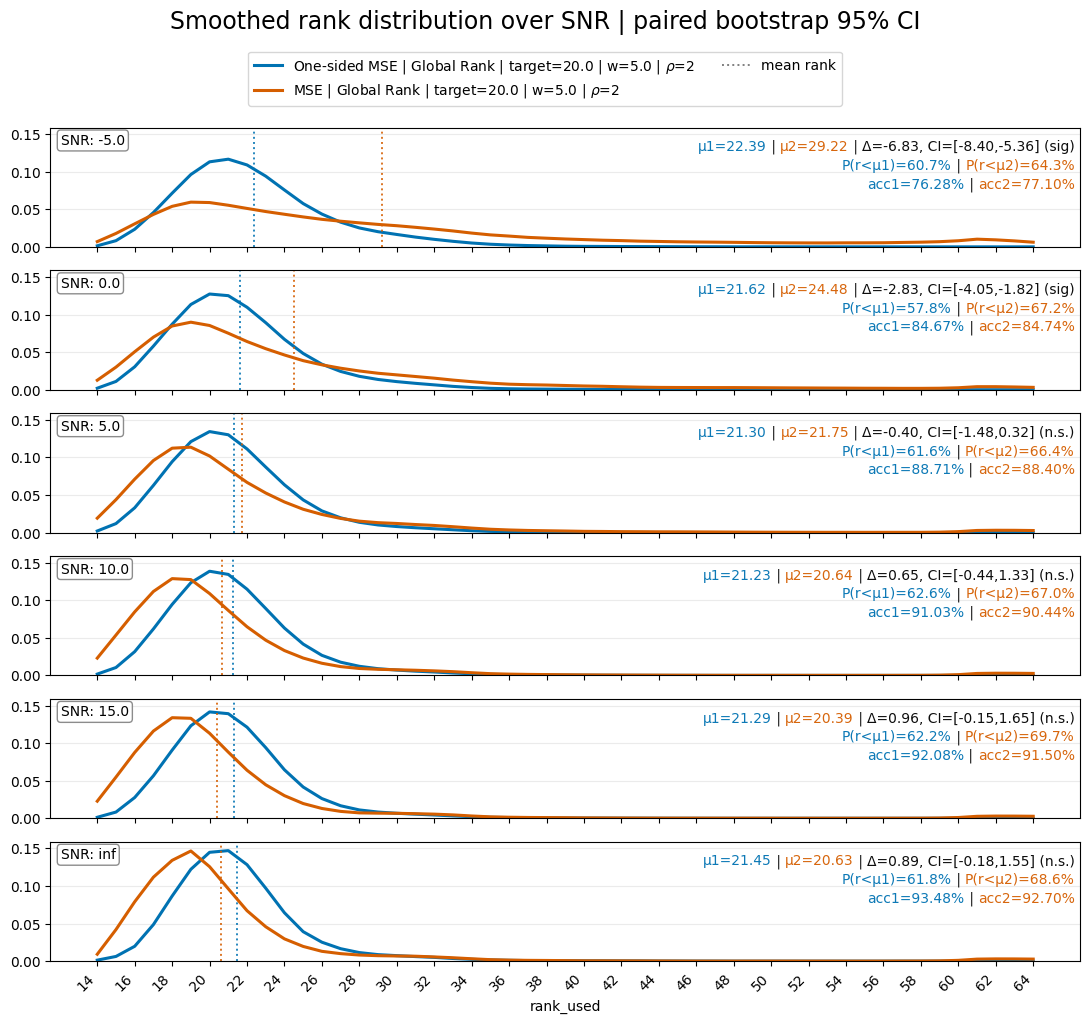


Global-rank sweeps: smoothed histogram rows by class
Paired bootstrap CI results (Class):


,label,model_1,model_2,mean_1,mean_2,mean_diff,ci_low,ci_high,ci_level,significant,n_pairs,mcnemar_p,mcnemar_p_ci_low,mcnemar_p_ci_high,mcnemar_significant,n01,n10
0,SILENCE,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,24.928982,31.871921,-6.961092,-10.755111,-3.491541,0.95,True,36,1.0,1.00,1.0,False,0.0,0.0
1,UNKNOWN,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.319308,22.035441,-0.713884,-2.230238,0.506640,0.95,False,36,1.0,0.25,1.0,False,1.0,0.0
2,down,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.031314,21.941202,-0.898524,-2.403409,0.305079,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
3,go,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.181750,22.059588,-0.870850,-2.540852,0.479501,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
4,left,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.187658,21.748422,-0.552948,-1.929205,0.555841,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
5,no,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.377874,22.286535,-0.902466,-2.440031,0.340850,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
6,off,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.463137,22.311439,-0.840778,-2.457762,0.447757,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
7,on,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.198883,22.028926,-0.828271,-2.476400,0.487313,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
8,right,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.077288,22.036425,-0.957592,-2.417600,0.246550,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0
9,stop,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,20.908730,21.440159,-0.535838,-2.071489,0.680930,0.95,False,36,1.0,1.00,1.0,False,0.0,0.0


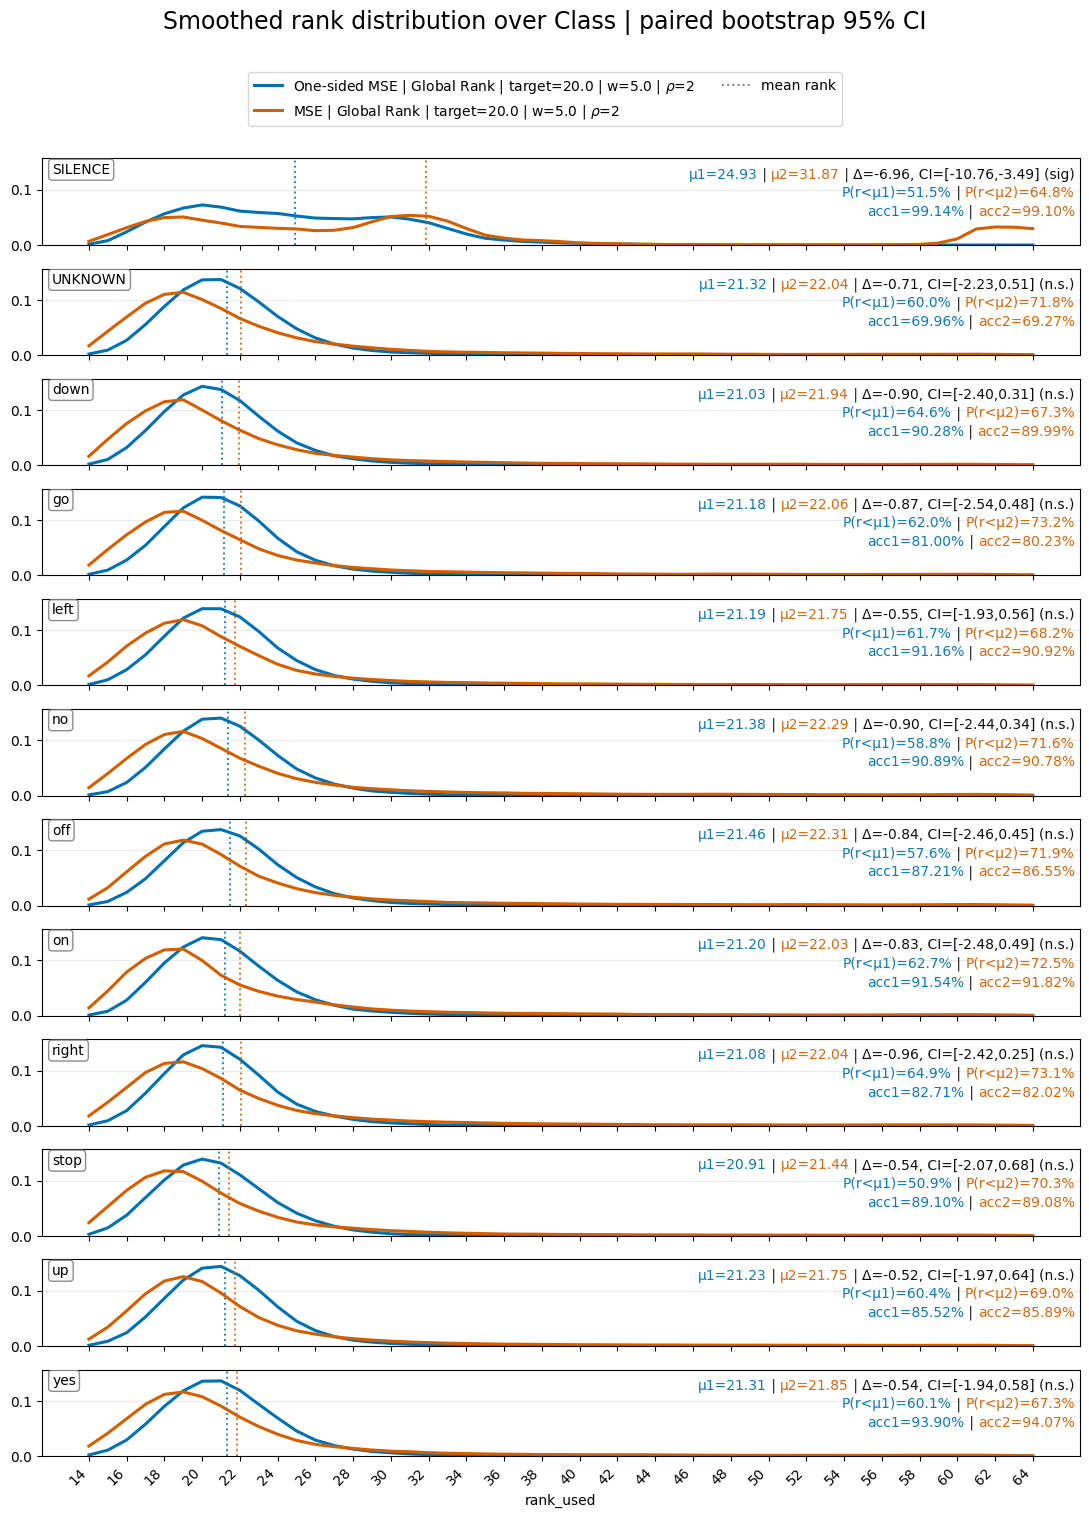


Global-rank sweeps: smoothed histogram rows by noise type
Paired bootstrap CI results (Noise):


,noise_type,model_1,model_2,mean_1,mean_2,mean_diff,ci_low,ci_high,ci_level,significant,n_pairs,mcnemar_p,mcnemar_p_ci_low,mcnemar_p_ci_high,mcnemar_significant,n01,n10
0,doing_the_dishes,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,22.431045,23.301993,-0.870331,-1.355512,-0.412448,0.95,True,72,1.0,1.00,1.0,False,0.0,0.0
1,dude_miaowing,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.383241,20.913104,0.478138,0.138035,0.799637,0.95,True,72,1.0,1.00,1.0,False,0.0,0.0
2,exercise_bike,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,20.065153,20.764120,-0.701296,-1.398872,-0.044650,0.95,True,72,1.0,1.00,1.0,False,0.0,0.0
3,pink_noise,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,21.702030,21.066851,0.705470,-0.032802,1.327861,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0
4,running_tap,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,20.473348,21.096382,-0.612036,-1.403618,0.121267,0.95,False,72,1.0,1.00,1.0,False,0.0,0.0
5,white_noise,One-sided MSE | Global Rank | target=20.0 | w=...,MSE | Global Rank | target=20.0 | w=5.0 | $\rh...,23.225397,29.966113,-6.557167,-9.043589,-4.195310,0.95,True,72,1.0,0.25,1.0,False,1.0,0.0


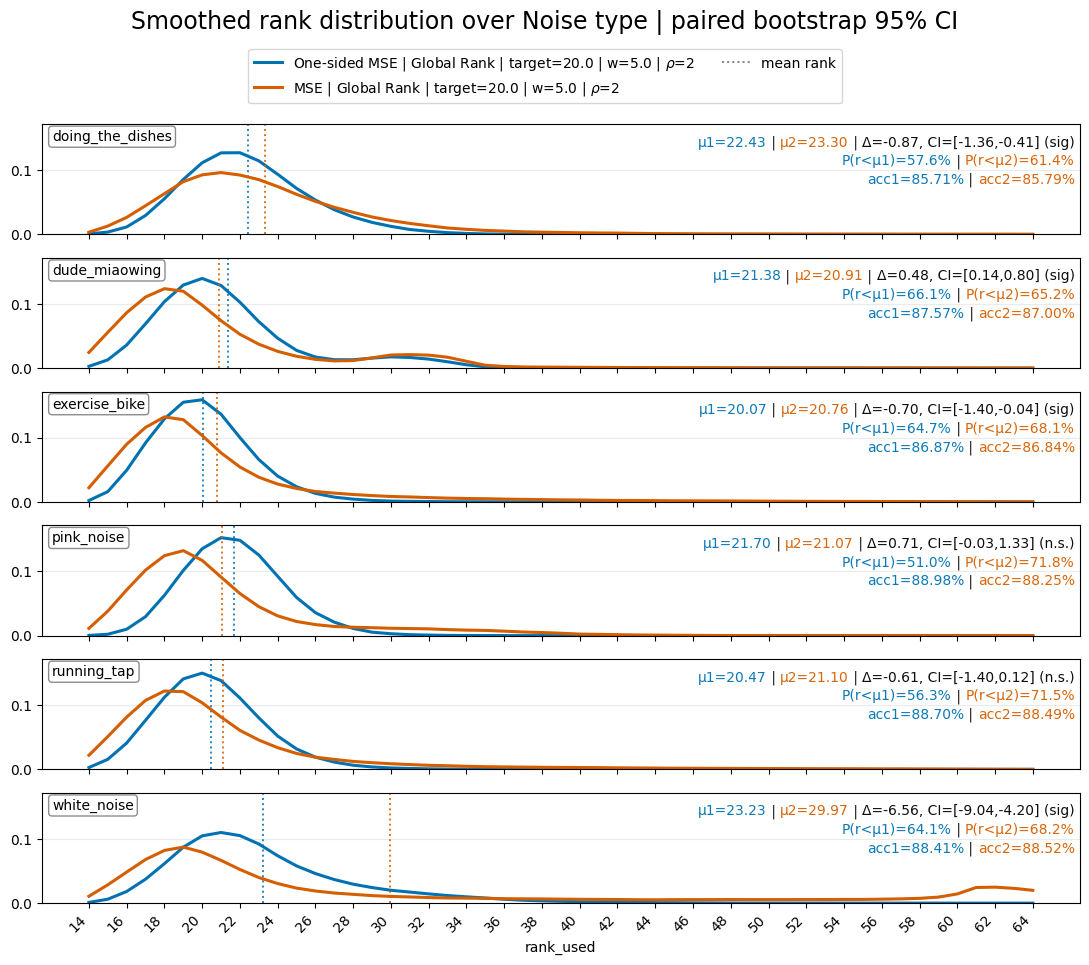

Saved rank distribution figures to: /Users/christoffer/Documents/Thesis/thesis_project/Figs_and_tables/dynamic_model_viz/rank_distributions


In [344]:

rank_distribution_output_dir = output_dir / "rank_distributions"

global_rank_results = plot_distributions_for_sweeps(
    sweeps_for_distribution_plots_global_rank,
    title_prefix="Global-rank sweeps",
    smooth_window=5,
    max_rank_cap=None,
    show_mcnemar_annotation=False,
    show_accuracy_annotation=True,
    show_iqr_annotation=False,
    save_figures=True,
    save_dir=rank_distribution_output_dir,
)


### ACCURACY OF MODELS AT DIFFERENT CLASS AND SNR